# PRT661 – Housing Affordability Forecasting System
## Assessment 2

**Group:** Dan1-Theme2 · **Theme 2 — Predictive Analytics and Forecasting**

**What this notebook does, in order:**
1. Load the four raw data files.
2. Run a set of reusable EDA (exploratory data analysis) checks on the raw data, so we know exactly what's wrong with it.
3. Clean each file based on what those checks found.
4. Run the same EDA checks again to confirm the cleaning worked.
5. Engineer a few extra features (distance to CBD, property type, etc).
6. Merge everything into one table.
7. Split into train/test **by time** (not randomly), because this is a forecasting problem.
8. Fill in missing values — using only the training data, so nothing "leaks" from the future.
9. Train three models (Linear Regression, Random Forest, XGBoost) and compare them.
10. Dig into *why* all three models struggle on 2025 sales, and try a few fixes.

Every EDA function below calls `note(...)` whenever it spots something worth acting on. All of
these notes get collected and printed together at the end (Section 13) as a simple audit trail:
"here's what we found, and here's what we did about it."


## Project Setup — Imports & Directories

In [ ]:
# Standard libraries
import re
import math
import warnings
from pathlib import Path

# Data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling tools
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor

import joblib

# Quality-of-life settings: hide warnings, use a clean plot style, show more columns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

# Fixed seed so results are reproducible
RANDOM_STATE = 19
np.random.seed(RANDOM_STATE)


In [ ]:
# Folder structure for the project's data
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"                 # original, untouched files
PROCESSED_DIR = DATA_DIR / "processed"     # cleaned individual files
MODEL_READY_DIR = DATA_DIR / "model_ready" # the final merged table used for modelling
OUTPUT_DIR = DATA_DIR / "output"           # predictions, saved models, metrics

for d in [RAW_DIR, PROCESSED_DIR, MODEL_READY_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Paths to the four raw input files
PROPERTIES_PATH = RAW_DIR / "properties.csv"
ERP_PATH = RAW_DIR / "ERP.csv"
ANNUAL_HOUSEHOLD_PATH = RAW_DIR / "Annual_Household_NT.csv"
CASH_RATE_PATH = RAW_DIR / "cash_rates.csv"

# Darwin CBD coordinates, used later to work out each property's distance from the city centre
DARWIN_CBD_LAT, DARWIN_CBD_LON = -12.4634, 130.8456


## 1. Loading Data

Four files go into this project:

- **`properties.csv`** — the property sales themselves.
- **`ERP.csv`** — the ABS's Estimated Resident Population for Greater Darwin, one row per year.
  We use the whole-of-region number here (instead of suburb-level data) because every property
  in this dataset is inside Greater Darwin, so it merges cleanly on `year` with no name-matching
  needed.
- **`Annual_Household_NT.csv`** — Northern Territory household income, one row per year.
- **`cash_rates.csv`** — the RBA's full history of cash rate changes. This one only has a row
  when the rate actually changed, so it can't be merged on `year` like the others — it needs a
  date-based join, which we do later in Section 5.1.


In [ ]:
def load_csv(path, name):
    """Loads a CSV and prints its shape so we can sanity-check the load."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find file at {path}.")
    df = pd.read_csv(path)
    print(f"Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    return df

properties_processed = load_csv(PROPERTIES_PATH, "Properties Dataset")
erp_raw = load_csv(ERP_PATH, "ERP Dataset (Greater Darwin Region)")
annual_household_raw = load_csv(ANNUAL_HOUSEHOLD_PATH, "Annual Household Income Dataset (NT)")
cash_rate_raw = load_csv(CASH_RATE_PATH, "RBA Cash Rate Target Dataset")


Loaded Properties Dataset: 15,423 rows x 18 columns
Loaded ERP Dataset (Greater Darwin Region): 21 rows x 2 columns
Loaded Annual Household Income Dataset (NT): 45 rows x 28 columns
Loaded RBA Cash Rate Target Dataset: 108 rows x 7 columns


In [ ]:
def check_data(df, name):
    """Quick first look at a dataframe: data types, missing values, and the first two rows."""
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(df.dtypes)
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing):
        print("\nMissing values:")
        print(missing)
    else:
        print("\nNo missing values.")
    display(df.head(2))

check_data(properties_processed, "Properties Dataset")
check_data(erp_raw, "ERP Dataset (Greater Darwin Region) — Number stored as text with thousands-separator commas")
check_data(annual_household_raw, "Annual Household Income Dataset (NT) — includes metadata rows to be cleaned")
check_data(cash_rate_raw, "RBA Cash Rate Target Dataset — real header sits on row 2 of the export, not row 1")



Properties Dataset
property_id            int64
address                  str
url                      str
status                   str
sold_date                str
sold_date_iso            str
price_text               str
price_numeric        float64
price_undisclosed       bool
beds                   int64
baths                  int64
cars                   int64
land_area_m2             str
latitude             float64
longitude            float64
agent_name               str
agency_name              str
suburb                   str
dtype: object

Missing values:
agent_name       13273
agency_name      13273
land_area_m2      5800
price_numeric     5088
price_text        5088
sold_date          250
sold_date_iso      250
longitude          226
latitude           226
dtype: int64


,property_id,address,url,status,sold_date,sold_date_iso,price_text,price_numeric,price_undisclosed,beds,baths,cars,land_area_m2,latitude,longitude,agent_name,agency_name,suburb
0,11245030,"22 Caledonian Street, Anula NT 812",https://www.homely.com.au/homes/22-caledonian-...,Sold,15 Aug 2024,2024-08-15T00:00:00+00:00,"$540,000",540000.0,False,3,1,2,985m²,-12.393042,130.887771,Ella Carling,Real Estate Central,anula-nt-0812
1,11057061,"52 Wandie Crescent, Anula NT 812",https://www.homely.com.au/homes/52-wandie-cres...,Sold,4 Jul 2024,2024-07-04T00:00:00+00:00,"$560,000",560000.0,False,3,1,3,743m²,-12.394495,130.893049,Simon Watts,Real Estate Central,anula-nt-0812



ERP Dataset (Greater Darwin Region) — Number stored as text with thousands-separator commas
Year      int64
Number      str
dtype: object

No missing values.


,Year,Number
0,2006,"1,13,461"
1,2007,"1,16,935"



Annual Household Income Dataset (NT) — includes metadata rows to be cleaned
Unnamed: 0                                                                                 str
Gross operating surplus ;  Dwellings owned by persons ;                                    str
Gross mixed income ;                                                                       str
Compensation of employees ;                                                                str
Total property income receivable ;                                                         str
Total primary income receivable ;                                                          str
Secondary income receivable - Social benefits receivable - Workers' compensation ;         str
Secondary income receivable - Social benefits receivable - Social assistance benefits ;    str
Secondary income receivable - Current transfers to non-profit institutions ;               str
Other secondary income ;                                            

,Unnamed: 0,Gross operating surplus ; Dwellings owned by persons ;,Gross mixed income ;,Compensation of employees ;,Total property income receivable ;,Total primary income receivable ;,Secondary income receivable - Social benefits receivable - Workers' compensation ;,Secondary income receivable - Social benefits receivable - Social assistance benefits ;,Secondary income receivable - Current transfers to non-profit institutions ;,Other secondary income ;,Total secondary income receivable ;,TOTAL GROSS INCOME ;,Property income payable - Interest - Dwellings ;,Property income payable - Interest - Consumer debt ;,Property income payable - Unincorporated enterprises ;,Total property income payable ;,Total primary income payable ;,Secondary income payable - Income tax ;,Secondary income payable - Social contributions for workers' compensation ;,"Secondary income payable - Other current taxes on income, wealth, etc. ;",Other secondary income ;.1,Total secondary income payable ;,Total income payable ;,GROSS DISPOSABLE INCOME ;,Final consumption expenditure ;,Net saving plus consumption of fixed capital ;,Total gross income per capita ;,Gross household disposable income per capita ;
0,Unit,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$,$
1,Series Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original



RBA Cash Rate Target Dataset — real header sits on row 2 of the export, not row 1
A2 RESERVE BANK OF AUSTRALIA – CHANGES IN MONETARY POLICY AND ADMINISTERED RATES    str
Unnamed: 1                                                                          str
Unnamed: 2                                                                          str
Unnamed: 3                                                                          str
Unnamed: 4                                                                          str
Unnamed: 5                                                                          str
Unnamed: 6                                                                          str
dtype: object

Missing values:
Unnamed: 3                                                                          20
Unnamed: 5                                                                          20
Unnamed: 4                                                                          19
Unnamed: 

,A2 RESERVE BANK OF AUSTRALIA – CHANGES IN MONETARY POLICY AND ADMINISTERED RATES,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Title,Change in Cash Rate Target,New Cash Rate Target,Change in ES Rate,New ES Rate,Change in Overnight Repo Rate,New Overnight Repo Rate
1,Description,Change in Cash Rate Target (in percentage points),The Cash Rate Target As Announced,Change in Rate Paid on Exchange Settlement Bal...,The New Rate Paid on Exchange Settlement Balances,Change in Pricing Rate on RBA Overnight Standi...,The New Pricing Rate on RBA Overnight Standing...


## 2. Reusable EDA Toolkit

Instead of writing one-off checks, this section builds a small toolkit of EDA functions we can
call three times: right after loading, again after cleaning, and again after merging. That way
we can actually see whether a cleaning step worked, instead of just assuming it did.

Whenever a check finds something worth acting on, it calls `note(stage, message)`. Every note
gets collected into `INSIGHTS` and printed together at the end (Section 13) as a simple log of
"found this → did that".


In [ ]:
INSIGHTS = []

def note(stage, message):
    """Logs a finding worth acting on. Prints it now, and saves it for the Section 13 summary."""
    INSIGHTS.append((stage, message))
    print(f"  \u2192 INSIGHT [{stage}]: {message}")


### 2.1 Missingness — same check, every stage

In [ ]:
def eda_missingness(datasets: dict, stage="RAW"):
    """Plots % missing values for each dataset side by side. datasets = {"name": dataframe, ...}"""
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5))
    if len(datasets) == 1:
        axes = [axes]
    for ax, (name, df) in zip(axes, datasets.items()):
        missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
        missing_pct = missing_pct[missing_pct > 0]
        if len(missing_pct) == 0:
            ax.text(0.5, 0.5, "No missing values", ha="center", va="center")
            ax.set_title(f"{name} ({stage})")
            ax.axis("off")
            continue
        sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color="#B00020")
        ax.set_title(f"{name} ({stage}) — % missing")
        ax.set_xlabel("% missing")
        # Flag columns that are missing enough to need a real decision
        for col, pct in missing_pct.items():
            if pct > 30:
                note(stage, f"'{col}' in {name} is {pct:.0f}% missing — decide: impute, drop column, or drop rows.")
            elif pct > 5:
                note(stage, f"'{col}' in {name} is {pct:.0f}% missing — plan and document an imputation strategy.")
    plt.tight_layout()
    plt.show()


### 2.2 Properties Profile
Also catches a couple of common raw-data quirks the first time it's called, so it's safe to run
before any cleaning has happened.


In [ ]:
def eda_properties_profile(df, stage="RAW"):
    """Profiles the properties dataset: price/size distributions, sales over time, suburbs,
    and a geographic scatter. Also auto-detects a few known raw-data issues so it's safe to
    run before cleaning."""
    print(f"\n{'='*70}\nPROPERTIES — {stage}\n{'='*70}")
    d = df.copy()

    # --- Spot common raw-data quirks automatically ---
    if "suburb" in d.columns:
        looks_like_slug = d["suburb"].astype(str).str.contains("-").mean() > 0.5
        if looks_like_slug:
            note(stage, "suburb looks like a URL slug (e.g. 'anula-nt-0812') — parse into a "
                         "clean name before joining with census/population data.")

    raw_land = d.get("land_area_m2")
    parsed_land = pd.to_numeric(raw_land, errors="coerce") if raw_land is not None else None
    if raw_land is not None:
        non_null_raw = raw_land.notna().sum()
        non_null_parsed = parsed_land.notna().sum() if parsed_land is not None else 0
        if non_null_raw > 0 and non_null_parsed / non_null_raw < 0.5:
            note(stage, "land_area_m2 looks like text with unit suffixes (e.g. '985m²') — "
                         "strip non-numeric characters before treating it as a number.")

    d["_price"] = pd.to_numeric(d.get("price_numeric"), errors="coerce")
    d["_land_area"] = parsed_land
    d["_sold_date"] = pd.to_datetime(d.get("sold_date_iso"), errors="coerce")
    d["_sale_year"] = d["_sold_date"].dt.year

    n_dupe = d.duplicated(subset=["property_id"]).sum() if "property_id" in d.columns else 0
    if n_dupe:
        note(stage, f"{n_dupe} duplicate property_id rows — deduplicate before modelling.")

    if "price_undisclosed" in d.columns and d["price_undisclosed"].dtype == object:
        note(stage, "price_undisclosed is stored as text ('true'/'false') — convert to 0/1 "
                     "before filtering on it.")

    print(f"Rows: {len(d):,} | Unique suburbs: {d['suburb'].nunique() if 'suburb' in d else 'n/a'} | "
          f"Sale years: {d['_sale_year'].min()}–{d['_sale_year'].max()}")

    # --- Six quick charts covering price, sales volume, house features, suburbs, and location ---
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))

    if d["_price"].notna().sum() > 0:
        sns.histplot(d["_price"].dropna(), bins=50, ax=axes[0, 0], color="#2E5090")
    axes[0, 0].set_title("Sale Price Distribution")

    if d["_price"].notna().sum() > 0:
        sns.histplot(np.log1p(d["_price"].dropna()), bins=50, ax=axes[0, 1], color="#2E5090")
    axes[0, 1].set_title("Log(Sale Price) Distribution")

    sales_per_year = d["_sale_year"].value_counts().sort_index()
    axes[0, 2].bar(sales_per_year.index.astype(str), sales_per_year.values, color="#2E5090")
    axes[0, 2].set_title("Number of Sales per Year")
    axes[0, 2].tick_params(axis="x", rotation=45)

    if {"beds", "baths", "cars"}.issubset(d.columns):
        bbc = d[["beds", "baths", "cars"]].melt(var_name="type", value_name="count")
        sns.countplot(data=bbc, x="count", hue="type", ax=axes[1, 0])
    axes[1, 0].set_title("Beds / Baths / Cars Distribution")

    if "suburb" in d.columns:
        top_suburbs = d["suburb"].value_counts().head(15)
        sns.barplot(x=top_suburbs.values, y=top_suburbs.index, ax=axes[1, 1], color="#2E5090")
    axes[1, 1].set_title("Top 15 Suburbs by Listing Count")

    if {"latitude", "longitude"}.issubset(d.columns):
        valid_geo = d.dropna(subset=["latitude", "longitude", "_price"])
        sc = axes[1, 2].scatter(valid_geo["longitude"], valid_geo["latitude"], c=valid_geo["_price"],
                                 cmap="viridis", s=14, alpha=0.6)
        axes[1, 2].scatter([DARWIN_CBD_LON], [DARWIN_CBD_LAT], marker="*", s=250, color="red", label="Darwin CBD")
        axes[1, 2].legend()
        plt.colorbar(sc, ax=axes[1, 2], label="Price (AUD)")
    axes[1, 2].set_title("Geographic Spread — colour = price")

    plt.tight_layout()
    plt.show()

    # --- Flag price outliers using the standard IQR rule ---
    if d["_price"].notna().sum() > 10:
        q1, q3 = d["_price"].quantile([0.25, 0.75])
        iqr = q3 - q1
        n_out = ((d["_price"] < q1 - 1.5 * iqr) | (d["_price"] > q3 + 1.5 * iqr)).sum()
        pct_out = n_out / d["_price"].notna().sum() * 100
        print(f"IQR-based price outliers: {n_out} ({pct_out:.1f}%)")
        if pct_out > 5:
            note(stage, f"{n_out} price outliers ({pct_out:.1f}%) — decide whether to cap, "
                         f"remove, or keep with justification before training a linear model "
                         f"(tree models are less sensitive to this).")
    return d


### 2.3 Annual Household Income Profile

This is now a proper year-by-year series (Assessment 1 used a single snapshot instead), so the
checks here focus on year coverage and the overall trend, not suburb comparisons.

There are around 27 raw income sub-accounts in this file. Rather than guessing which ones
matter, this groups them by how correlated they are and keeps one representative from each
group. Whatever comes out of that gets used later — no manual overriding.


In [ ]:
def eda_annual_household_profile(df, stage="RAW", corr_threshold=0.9):
    """Needs a 'year' column plus numeric indicator columns. There are ~27 raw NT income
    sub-accounts here that mostly track the same underlying economy, so instead of guessing
    which ones matter, this clusters them by correlation and keeps one rep per cluster.
    Returns None at RAW stage since 'year' isn't parsed yet."""
    print(f"\n{'='*70}\nANNUAL HOUSEHOLD INCOME (NT) — {stage}\n{'='*70}")

    if "year" not in df.columns:
        note(stage, "Annual household dataset has no parsed 'year' column yet — "
                     "parse the 'Jun-YYYY' style period labels before using this data. "
                     "(Which indicators matter can't be determined before that parsing anyway.)")
        return None

    year_min, year_max = int(df["year"].min()), int(df["year"].max())
    print(f"Year coverage: {year_min}\u2013{year_max} ({df['year'].nunique()} years)")

    gap_years = sorted(set(range(year_min, year_max + 1)) - set(df["year"].unique()))
    if gap_years:
        note(stage, f"Annual household series has gap year(s): {gap_years} — "
                     f"sales in those years won't get a match on this dataset.")

    numeric_cols = [c for c in df.columns if c != "year" and pd.api.types.is_numeric_dtype(df[c])]
    corr = df[numeric_cols].corr().abs()

    plt.figure(figsize=(30, 15))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
    plt.title(f"Annual Household Income — Correlation ({stage})")
    plt.tight_layout()
    plt.show()

    # --- Group columns that move together, keep one representative per group ---
    remaining = list(numeric_cols)
    clusters = []
    while remaining:
        seed = remaining[0]
        cluster = [c for c in remaining if corr.loc[seed, c] >= corr_threshold]
        clusters.append(cluster)
        remaining = [c for c in remaining if c not in cluster]

    key_indicators = []
    for cluster in clusters:
        if len(cluster) == 1:
            key_indicators.append(cluster[0])
            continue
        avg_corr_within = corr.loc[cluster, cluster].mean().sort_values(ascending=False)
        rep = avg_corr_within.index[0]
        key_indicators.append(rep)
        dropped = [c for c in cluster if c != rep]
        note(stage, f"Indicators {cluster} are highly correlated (>= {corr_threshold}) — kept "
                     f"'{rep}' as the representative, dropped {dropped} to reduce multicollinearity.")

    note(stage, f"Derived {len(key_indicators)} representative indicator(s) from "
                 f"{len(numeric_cols)} raw NT income sub-accounts via correlation clustering: "
                 f"{key_indicators}")

    note(stage, "This dataset is NT-WIDE, not suburb-level — every suburb receives the same "
                 "figure for a given year. This trades away suburb-level income granularity in "
                 "exchange for full 1990–2025 year coverage.")

    return key_indicators


### 2.4 ERP Profile
Same idea as the household check above — year coverage and trend — since there's no suburb
dimension here to compare.


In [ ]:
def eda_erp_profile(df, stage="RAW"):
    """df has a year column and a population column, one row per year, for Greater Darwin as
    a whole. There's no suburb dimension, so the checks focus on year coverage and the overall
    population trend."""
    print(f"\n{'='*70}\nERP — GREATER DARWIN REGION — {stage}\n{'='*70}")
    d = df.copy()

    year_col = "Year" if "Year" in d.columns else "year"
    pop_col = "Number" if "Number" in d.columns else "population"

    if d[pop_col].dtype == object:
        note(stage, f"'{pop_col}' in ERP is stored as text with thousands-separator commas "
                     f"(e.g. '1,63,219') — strip commas before treating it as numeric.")

    d["_year"] = pd.to_numeric(d[year_col], errors="coerce")
    d["_population"] = pd.to_numeric(
        d[pop_col].astype(str).str.replace(",", "", regex=False), errors="coerce"
    )
    d = d.dropna(subset=["_year"]).sort_values("_year")

    year_min, year_max = int(d["_year"].min()), int(d["_year"].max())
    print(f"Year coverage: {year_min}–{year_max} ({d['_year'].nunique()} years)")

    gap_years = sorted(set(range(year_min, year_max + 1)) - set(d["_year"].unique()))
    if gap_years:
        note(stage, f"ERP series has gap year(s): {gap_years} — "
                     f"sales in those years won't get a direct ERP match.")

    plt.figure(figsize=(10, 4))
    plt.plot(d["_year"], d["_population"], marker="o", color="#2E5090")
    plt.title(f"Greater Darwin Estimated Resident Population ({stage})")
    plt.xlabel("Year"); plt.ylabel("Population")
    plt.tight_layout(); plt.show()

    # Flag any year where population jumped or dropped sharply (possible data/boundary issue)
    pct_change = d["_population"].pct_change() * 100
    big_swings = d.loc[pct_change.abs() > 15, "_year"].tolist()
    if big_swings:
        note(stage, f"Year(s) with >15% YoY change in Greater Darwin ERP: {big_swings} — "
                     f"worth sanity-checking against ABS boundary/methodology revisions.")

    return d


### 2.5 RBA Cash Rate Profile

This series only has a row when the rate actually changed, so gaps of months or years between
rows are completely normal — not a data problem. At RAW stage this can only tell us whether the
header has been parsed correctly yet; once cleaned, it plots the actual rate path and flags any
single move that looks unusually large.


In [ ]:
def eda_cash_rate_profile(df, stage="RAW"):
    """df is one row per RBA cash-rate CHANGE, not one row per year/month, so there's no
    year-coverage/gap check here like the other datasets — gaps are expected. Instead this
    checks whether the file is parsed into a clean (date, cash_rate_target) shape yet, and, if
    so, plots the trend and flags unusually large single moves."""
    print(f"\n{'='*70}\nRBA CASH RATE TARGET — {stage}\n{'='*70}")

    if "date" not in df.columns or "cash_rate_target" not in df.columns:
        note(stage, "RBA cash rate export's real column headers sit on row 2 (row 1 is just a "
                     "report title), and rows 3-11 are further metadata (Description/Frequency/"
                     "Units/Source/Publication date/Series ID) -- reparse the header from row 2 "
                     "and keep only rows whose first column is a valid date.")
        return None

    d = df.dropna(subset=["date"]).sort_values("date").copy()
    print(f"Rate-change events: {len(d):,} | Date range: {d['date'].min().date()} to "
          f"{d['date'].max().date()}")

    plt.figure(figsize=(11, 4))
    plt.step(d["date"], d["cash_rate_target"], where="post", color="#2E5090")
    plt.title(f"RBA Cash Rate Target Over Time ({stage})")
    plt.xlabel("Date"); plt.ylabel("Cash rate target (%)")
    plt.tight_layout(); plt.show()

    # Flag any year with an unusually large single rate move
    d["_step_change"] = d["cash_rate_target"].diff()
    sharp_years = sorted(d.loc[d["_step_change"].abs() >= 1.0, "date"].dt.year.unique().tolist())
    if sharp_years:
        note(stage, f"Year(s) with a single RBA move of >=1.00 percentage point: {sharp_years} "
                     f"— these are the sharpest affordability shocks in the series, worth "
                     f"checking against the property test-set years for regime-shift effects.")
    return d


### 2.6 Orchestrator
Runs everything above in one call, so we're not copy-pasting the same four lines at every stage.


In [ ]:
def run_full_eda(properties_df, annual_household_df, erp_df, stage="RAW"):
    """Runs the whole EDA toolkit at a given stage. Call it again after cleaning, and a third
    time after merging, to see exactly what changed.

    Returns (household_key_indicators, erp_clean), both worked out DURING this pass. At RAW
    stage household_key_indicators is None (year isn't parsed yet); at CLEANED stage it's the
    correlation-clustered list this pass found.
    """
    print(f"\n{'#'*70}\n# FULL EDA PASS — STAGE: {stage}\n{'#'*70}")
    eda_missingness(
        {"properties": properties_df, "annual_household": annual_household_df, "erp": erp_df},
        stage=stage
    )
    eda_properties_profile(properties_df, stage=stage)
    household_key_indicators = eda_annual_household_profile(annual_household_df, stage=stage)
    erp_clean = eda_erp_profile(erp_df, stage=stage)
    return household_key_indicators, erp_clean


## 2.7 EDA Pass 1 — Data As Loaded

Running the checks before touching anything, so the cleaning decisions in Section 3 are based on
what's actually wrong, not on assumptions. The slug-suburb and text-land-area warnings below both
come straight out of this pass.



######################################################################
# FULL EDA PASS — STAGE: RAW
######################################################################
  → INSIGHT [RAW]: 'agency_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'agent_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'land_area_m2' in properties is 38% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'price_numeric' in properties is 33% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'price_text' in properties is 33% missing — decide: impute, drop column, or drop rows.


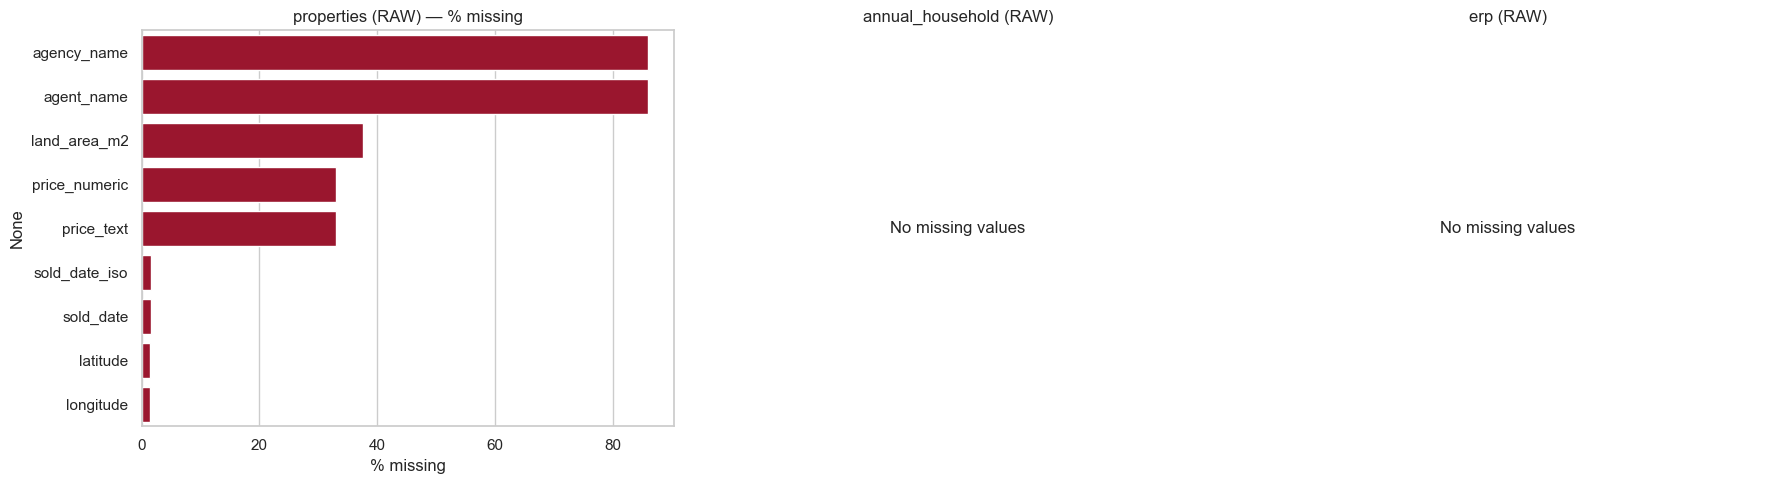


PROPERTIES — RAW
  → INSIGHT [RAW]: suburb looks like a URL slug (e.g. 'anula-nt-0812') — parse into a clean name before joining with census/population data.
  → INSIGHT [RAW]: land_area_m2 looks like text with unit suffixes (e.g. '985m²') — strip non-numeric characters before treating it as a number.
Rows: 15,423 | Unique suburbs: 74 | Sale years: 1920.0–2026.0


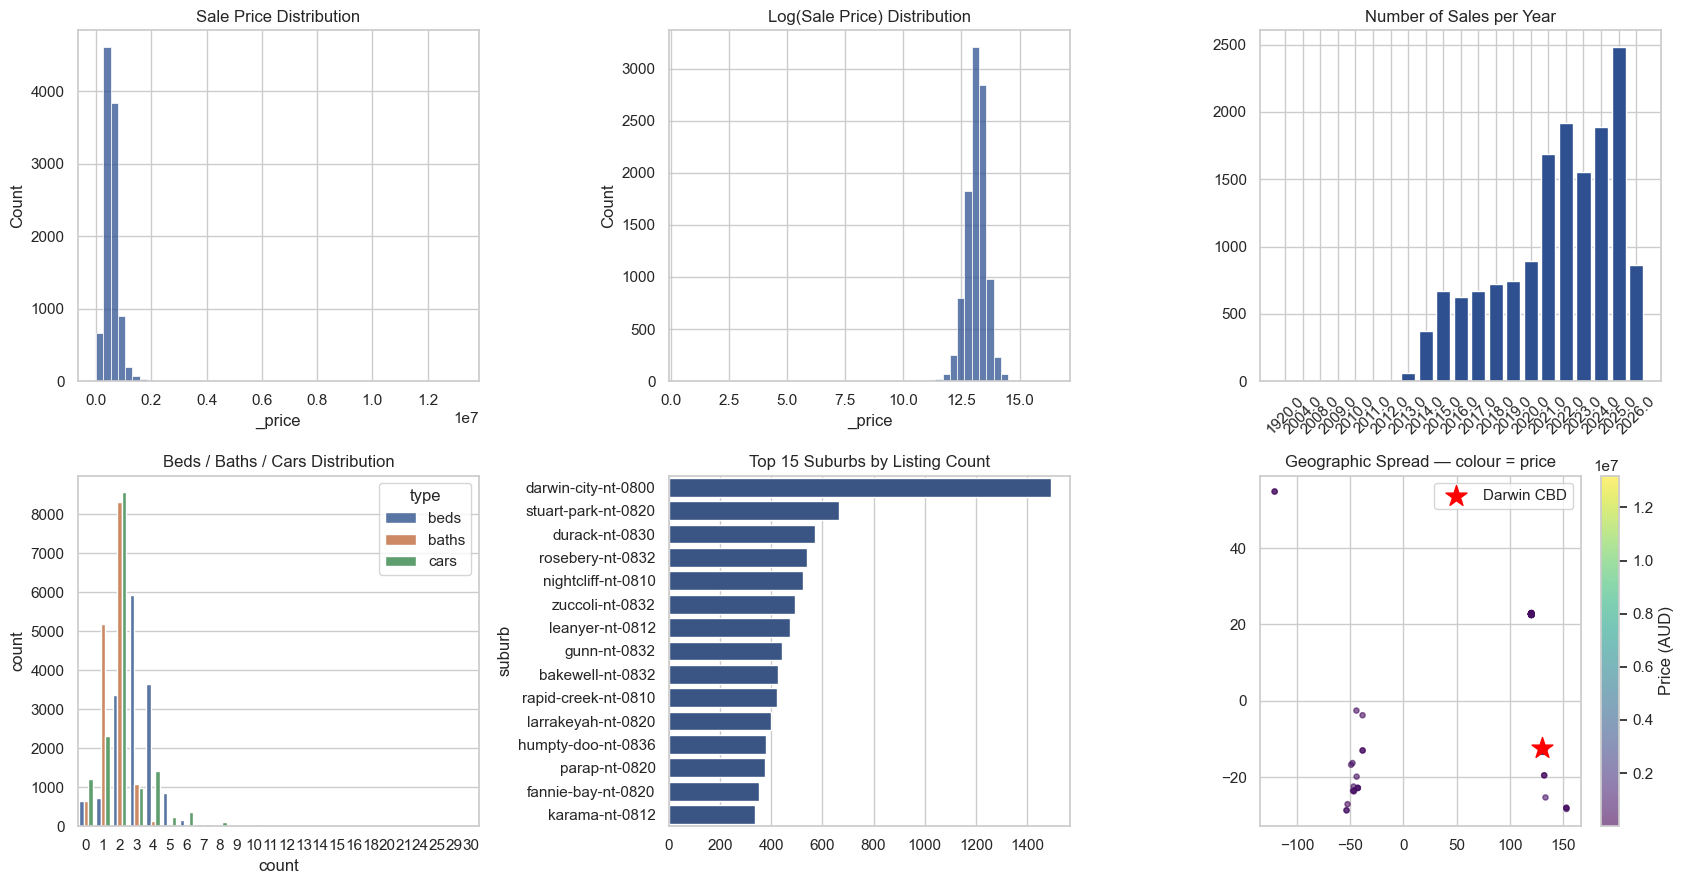

IQR-based price outliers: 337 (3.3%)

ANNUAL HOUSEHOLD INCOME (NT) — RAW
  → INSIGHT [RAW]: Annual household dataset has no parsed 'year' column yet — parse the 'Jun-YYYY' style period labels before using this data. (Which indicators matter can't be determined before that parsing anyway.)

ERP — GREATER DARWIN REGION — RAW
Year coverage: 2006–2026 (21 years)


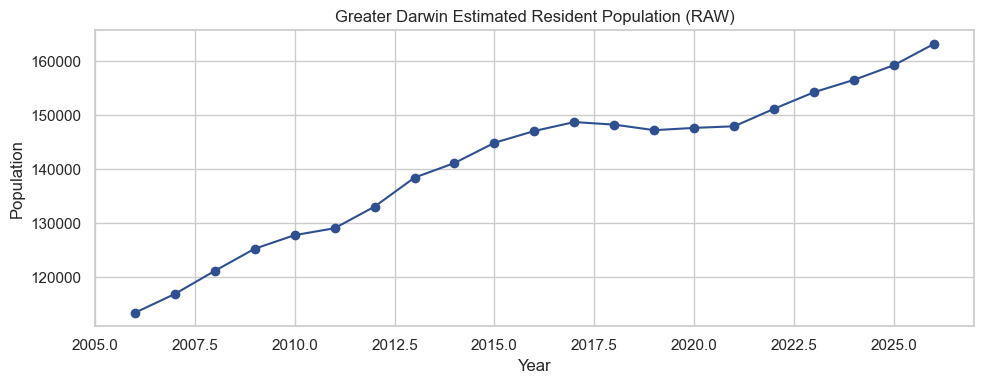


RBA CASH RATE TARGET — RAW
  → INSIGHT [RAW]: RBA cash rate export's real column headers sit on row 2 (row 1 is just a report title), and rows 3-11 are further metadata (Description/Frequency/Units/Source/Publication date/Series ID) -- reparse the header from row 2 and keep only rows whose first column is a valid date.


In [ ]:
household_key_indicators_raw, _ = run_full_eda(
    properties_processed, annual_household_raw, erp_raw, stage="RAW"
)
# household_key_indicators_raw is None here -- 'year' hasn't been parsed on
# annual_household_raw yet, so nothing can be derived at this stage.

eda_cash_rate_profile(cash_rate_raw, stage="RAW")
# Also None at RAW stage -- the RBA export's real header sits on row 2, not row 1,
# so 'date'/'cash_rate_target' don't exist as columns yet.


## 3. Data Cleaning
Working through each issue the RAW pass flagged, one dataset at a time.


### 3.1 Properties

What the RAW pass found:

- `suburb` is a URL slug (`anula-nt-0812`), not a real name.
- `land_area_m2` is text with a unit stuck on the end (`985m²`).
- `price_undisclosed` is the string `"false"`/`"true"`, not `0`/`1`.
- Some rows have `price_text` but no `price_numeric` — worth trying to recover before dropping.

Fix: split the slug apart, convert price/land-area to numbers, fix the undisclosed flag, drop
duplicates, and filter outliers using the IQR method.


In [ ]:
def parse_suburb_slug(slug):
    """Turns a URL slug like 'coconut-grove-nt-0810' into (suburb, state, postcode)."""
    if pd.isna(slug):
        return pd.Series([np.nan, np.nan, np.nan])
    parts = str(slug).strip().lower().split("-")
    postcode, state = np.nan, np.nan
    if parts and parts[-1].isdigit():
        postcode, parts = parts[-1], parts[:-1]
    if parts and parts[-1].isalpha() and len(parts[-1]) <= 3:
        state, parts = parts[-1].upper(), parts[:-1]
    suburb = " ".join(p.capitalize() for p in parts) if parts else np.nan
    return pd.Series([suburb, state, postcode])


def parse_land_area(value):
    """Strips units like 'm²' off a land-area value and returns a plain number."""
    if pd.isna(value):
        return np.nan
    digits = re.sub(r"[^0-9.]", "", str(value))
    return float(digits) if digits else np.nan


def parse_bool_ish(value):
    """Converts text like 'true'/'false'/'yes'/'no' into a proper 0/1 flag."""
    if isinstance(value, bool):
        return int(value)
    s = str(value).strip().lower()
    if s in ("true", "1", "yes"):
        return 1
    if s in ("false", "0", "no", "nan", ""):
        return 0
    return 0


properties = properties_processed.copy()

# Split the suburb slug into a clean suburb name, state, and postcode
properties["suburb_raw"] = properties["suburb"]
properties[["suburb", "state", "postcode"]] = properties["suburb_raw"].apply(parse_suburb_slug)
print("Example suburb parsing:")
print(properties[["suburb_raw", "suburb", "state", "postcode"]].drop_duplicates().head(8).to_string(index=False))

properties["sold_date_iso"] = pd.to_datetime(properties["sold_date_iso"], errors="coerce")

if "land_area_m2" in properties.columns:
    properties["land_area_m2"] = properties["land_area_m2"].apply(parse_land_area)

if "price_undisclosed" in properties.columns:
    properties["price_undisclosed"] = properties["price_undisclosed"].apply(parse_bool_ish)
else:
    properties["price_undisclosed"] = 0

# Try to recover a numeric price from price_text where price_numeric is missing
properties["price_numeric"] = pd.to_numeric(properties["price_numeric"], errors="coerce")
if "price_text" in properties.columns:
    needs_fallback = properties["price_numeric"].isna() & properties["price_text"].notna()
    fallback_prices = properties.loc[needs_fallback, "price_text"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    properties.loc[needs_fallback, "price_numeric"] = pd.to_numeric(fallback_prices, errors="coerce")
    print(f"Recovered {needs_fallback.sum()} prices from price_text via fallback parsing.")

# Drop rows we can't use: no price, duplicates, or missing key fields
n_before = len(properties)
properties = properties[(properties["price_undisclosed"] == 0) & properties["price_numeric"].notna()].copy()
print(f"Dropped {n_before - len(properties)} rows with undisclosed/missing price ({len(properties)} remain).")

n_before = len(properties)
properties = properties.drop_duplicates(subset=["property_id"])
print(f"Removed {n_before - len(properties)} duplicate records ({len(properties)} remain).")

n_before = len(properties)
properties = properties.dropna(subset=["latitude", "longitude", "sold_date_iso"])
print(f"Dropped {n_before - len(properties)} rows missing coordinates/sale date ({len(properties)} remain).")

# --- Filter outliers using the IQR rule, without touching missing values ---
def iqr_filter(df, col, k=1.5):
    """Keeps rows within [Q1 - k*IQR, Q3 + k*IQR] for the given column. Missing values pass through."""
    valid = df[col].notna()
    q1, q3 = df.loc[valid, col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = ~valid | df[col].between(q1 - k * iqr, q3 + k * iqr)
    return df[mask], (~mask).sum()

# Keep only the years covered by BOTH macro datasets (ERP: 2006-2026, household income: to 2025)
PROPERTIES_YEAR_MIN, PROPERTIES_YEAR_MAX = 2006, 2025
n_before = len(properties)
properties = properties[properties["sold_date_iso"].dt.year.between(PROPERTIES_YEAR_MIN, PROPERTIES_YEAR_MAX)]
print(f"Restricted to sale years {PROPERTIES_YEAR_MIN}\u2013{PROPERTIES_YEAR_MAX} (ERP \u2229 "
      f"annual_household coverage): dropped {n_before - len(properties)} rows outside macro-data "
      f"coverage ({len(properties)} remain).")

n_before = len(properties)
properties, n_out_price = iqr_filter(properties, "price_numeric")
properties, n_out_land = iqr_filter(properties, "land_area_m2")
print(f"IQR outlier filtering removed {n_out_price} price outliers and {n_out_land} land-area outliers ({len(properties)} remain).")

print(f"\nFinal cleaned properties dataset: {len(properties):,} rows.")
properties.to_csv(PROCESSED_DIR / "properties_clean.csv", index=False)


Example suburb parsing:
           suburb_raw        suburb state postcode
        anula-nt-0812         Anula    NT     0812
      bayview-nt-0820       Bayview    NT     0820
coconut-grove-nt-0810 Coconut Grove    NT     0810
  darwin-city-nt-0800   Darwin City    NT     0800
   fannie-bay-nt-0820    Fannie Bay    NT     0820
      jingili-nt-0810       Jingili    NT     0810
       karama-nt-0812        Karama    NT     0812
   larrakeyah-nt-0820    Larrakeyah    NT     0820
Recovered 0 prices from price_text via fallback parsing.
Dropped 5088 rows with undisclosed/missing price (10335 remain).
Removed 0 duplicate records (10335 remain).
Dropped 126 rows missing coordinates/sale date (10209 remain).
Restricted to sale years 2006–2025 (ERP ∩ annual_household coverage): dropped 696 rows outside macro-data coverage (9513 remain).
IQR outlier filtering removed 301 price outliers and 876 land-area outliers (8336 remain).

Final cleaned properties dataset: 8,336 rows.


### 3.2 Annual Household Income

What the RAW pass flagged: a few metadata rows sitting above the real data (Unit, Series Type,
Frequency, etc.), a period column like `"Jun-1990"` that needs turning into a plain year, and
column names with a trailing `" ;"` and inconsistent casing.


In [ ]:
def clean_column_name(col):
    """Turns a messy column name into clean snake_case."""
    col = col.strip().rstrip(";").strip()
    col = re.sub(r"[^0-9a-zA-Z]+", "_", col).strip("_").lower()
    return col

annual_household = annual_household_raw.copy()
annual_household = annual_household.rename(columns={annual_household.columns[0]: "period"})

# Keep only rows that look like "Mon-YYYY" -- this drops any leftover metadata rows
valid_period = annual_household["period"].astype(str).str.match(r"^[A-Za-z]{3}-\d{4}$")
n_dropped = (~valid_period).sum()
if n_dropped:
    print(f"Dropped {n_dropped} non-data (metadata) row(s): "
          f"{annual_household.loc[~valid_period, 'period'].tolist()}")
annual_household = annual_household[valid_period].copy()

# Turn "Jun-1990" into 1990 (using the financial year label as the join year)
annual_household["year"] = pd.to_datetime(annual_household["period"], format="%b-%Y").dt.year
annual_household = annual_household.drop(columns=["period"])

# Clean up column names, and tell apart the two different "Other secondary income" columns
new_names = {}
seen_other_secondary = 0
for col in annual_household.columns:
    if col == "year":
        continue
    clean = clean_column_name(col)
    if clean == "other_secondary_income":
        seen_other_secondary += 1
        clean = "other_secondary_income_receivable" if seen_other_secondary == 1 else "other_secondary_income_payable"
    new_names[col] = clean
annual_household = annual_household.rename(columns=new_names)

# Make sure every indicator column is numeric
for col in annual_household.columns:
    if col != "year":
        annual_household[col] = pd.to_numeric(annual_household[col], errors="coerce")

print(f"Cleaned annual_household: {annual_household.shape[0]} years x {annual_household.shape[1]} columns")
print(f"Year range: {annual_household['year'].min()}\u2013{annual_household['year'].max()}")
annual_household.to_csv(PROCESSED_DIR / "annual_household_clean.csv", index=False)
annual_household.tail()


Dropped 9 non-data (metadata) row(s): ['Unit', 'Series Type', 'Data Type', 'Frequency', 'Collection Month', 'Series Start', 'Series End', 'No. Obs', 'Series ID']
Cleaned annual_household: 36 years x 28 columns
Year range: 1990–2025


,gross_operating_surplus_dwellings_owned_by_persons,gross_mixed_income,compensation_of_employees,total_property_income_receivable,total_primary_income_receivable,secondary_income_receivable_social_benefits_receivable_workers_compensation,secondary_income_receivable_social_benefits_receivable_social_assistance_benefits,secondary_income_receivable_current_transfers_to_non_profit_institutions,other_secondary_income_receivable,total_secondary_income_receivable,total_gross_income,property_income_payable_interest_dwellings,property_income_payable_interest_consumer_debt,property_income_payable_unincorporated_enterprises,total_property_income_payable,total_primary_income_payable,secondary_income_payable_income_tax,secondary_income_payable_social_contributions_for_workers_compensation,secondary_income_payable_other_current_taxes_on_income_wealth_etc,other_secondary_income_1,total_secondary_income_payable,total_income_payable,gross_disposable_income,final_consumption_expenditure,net_saving_plus_consumption_of_fixed_capital,total_gross_income_per_capita,gross_household_disposable_income_per_capita,year
40,2577,2046,11624,1880,18126,70,1560,211,512,2353,20479,348,76,33,457,457,2035,69,37,588,2729,3186,17293,11263,6030,82635,69780,2021
41,2855,2279,12362,2177,19673,82,1526,261,554,2423,22096,326,67,35,429,429,2175,86,37,647,2945,3374,18722,12142,6580,88206,74738,2022
42,3147,2294,12984,2433,20857,90,1442,311,532,2376,23233,594,77,68,740,740,2486,100,39,691,3316,4055,19178,13319,5859,91006,75121,2023
43,3349,2289,13862,2570,22069,97,1573,321,630,2621,24690,765,95,82,942,942,2759,108,40,720,3626,4568,20122,14237,5886,95307,77673,2024
44,3441,2598,15080,2733,23853,106,1675,295,668,2744,26597,786,99,132,1017,1017,2820,117,46,764,3746,4763,21833,14975,6858,101440,83273,2025


### 3.3 ERP

Much simpler than the others — one row per year, 2006–2026. The only issue is the population
column being stored as text with comma separators. Once that's stripped, it's ready to merge
on `year`.


In [ ]:
erp = erp_raw.copy()
erp = erp.rename(columns={"Year": "year", "Number": "population"})
# Strip the thousands-separator commas, then convert to a real number
erp["population"] = pd.to_numeric(erp["population"].astype(str).str.replace(",", "", regex=False), errors="coerce")
erp["year"] = pd.to_numeric(erp["year"], errors="coerce").astype(int)
erp = erp.sort_values("year").reset_index(drop=True)
erp.to_csv(PROCESSED_DIR / "erp_clean.csv", index=False)
erp.head()


,year,population
0,2006,113461
1,2007,116935
2,2008,121210
3,2009,125315
4,2010,127829


### 3.4 RBA Cash Rate

The RAW pass flagged that the real headers sit on row 2 of this export (row 1 is just a title).
A few more metadata rows follow before the actual data starts.

Also: a handful of pre-1994 rows report the target as a range (`"17.00 to 17.50"`) instead of a
single number, from back when the RBA used a corridor rather than a point target. None of the
Darwin sales in this dataset are anywhere near that old, but the parser still needs to handle
those rows without breaking.


In [ ]:
def parse_rate_value(value):
    """Most rows are a single number. A handful of pre-1994 rows report a range
    (e.g. '17.00 to 17.50') -- those are resolved to their midpoint."""
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if " to " in s:
        lo, hi = s.split(" to ")
        return (float(lo) + float(hi)) / 2
    return float(s)


cash_rate = cash_rate_raw.copy()

# Recover the real header from row 2 of the export (row 1 was just a title, already
# picked up as the header by the generic load_csv() call in Section 1)
real_header = cash_rate.iloc[0].tolist()
real_header[0] = "date"
cash_rate.columns = real_header
cash_rate = cash_rate.iloc[1:].reset_index(drop=True)

# Keep only rows whose first column is a genuine 'DD-Mon-YYYY' date -- this drops every
# remaining metadata row automatically
parsed_date = pd.to_datetime(cash_rate["date"], format="%d-%b-%Y", errors="coerce")
n_dropped = int(parsed_date.isna().sum())
cash_rate = cash_rate.loc[parsed_date.notna()].copy()
cash_rate["date"] = parsed_date.loc[parsed_date.notna()]
# Match properties["sold_date_iso"]'s timezone so merge_asof's join keys line up
# (otherwise it raises a MergeError)
if pd.api.types.is_datetime64_any_dtype(properties["sold_date_iso"]) and \
        properties["sold_date_iso"].dt.tz is not None:
    cash_rate["date"] = cash_rate["date"].dt.tz_localize(properties["sold_date_iso"].dt.tz)
print(f"Dropped {n_dropped} non-data (header/metadata) row(s) from the RBA export.")

cash_rate = cash_rate.rename(columns={"New Cash Rate Target": "cash_rate_target"})
cash_rate["cash_rate_target"] = cash_rate["cash_rate_target"].apply(parse_rate_value)
cash_rate = cash_rate[["date", "cash_rate_target"]].sort_values("date").reset_index(drop=True)

print(f"Cleaned cash_rate: {cash_rate.shape[0]} rate-change events "
      f"({cash_rate['date'].min().date()} to {cash_rate['date'].max().date()})")
cash_rate.to_csv(PROCESSED_DIR / "cash_rate_clean.csv", index=False)
cash_rate.tail()


Dropped 9 non-data (header/metadata) row(s) from the RBA export.
Cleaned cash_rate: 98 rate-change events (1990-01-23 to 2026-05-06)


,date,cash_rate_target
93,2025-05-21 00:00:00+00:00,3.85
94,2025-08-13 00:00:00+00:00,3.60
95,2026-02-04 00:00:00+00:00,3.85
96,2026-03-18 00:00:00+00:00,4.10
97,2026-05-06 00:00:00+00:00,4.35


## 3.5 EDA Pass 2 — After Cleaning

Same checks, same data, now run after cleaning. Compared to Pass 1: the slug/land-area warnings
should be gone, the household series should show a proper 1990–2025 range, and the cash rate
plot should actually render this time.



######################################################################
# FULL EDA PASS — STAGE: CLEANED
######################################################################
  → INSIGHT [CLEANED]: 'agent_name' in properties is 79% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [CLEANED]: 'agency_name' in properties is 79% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [CLEANED]: 'land_area_m2' in properties is 41% missing — decide: impute, drop column, or drop rows.


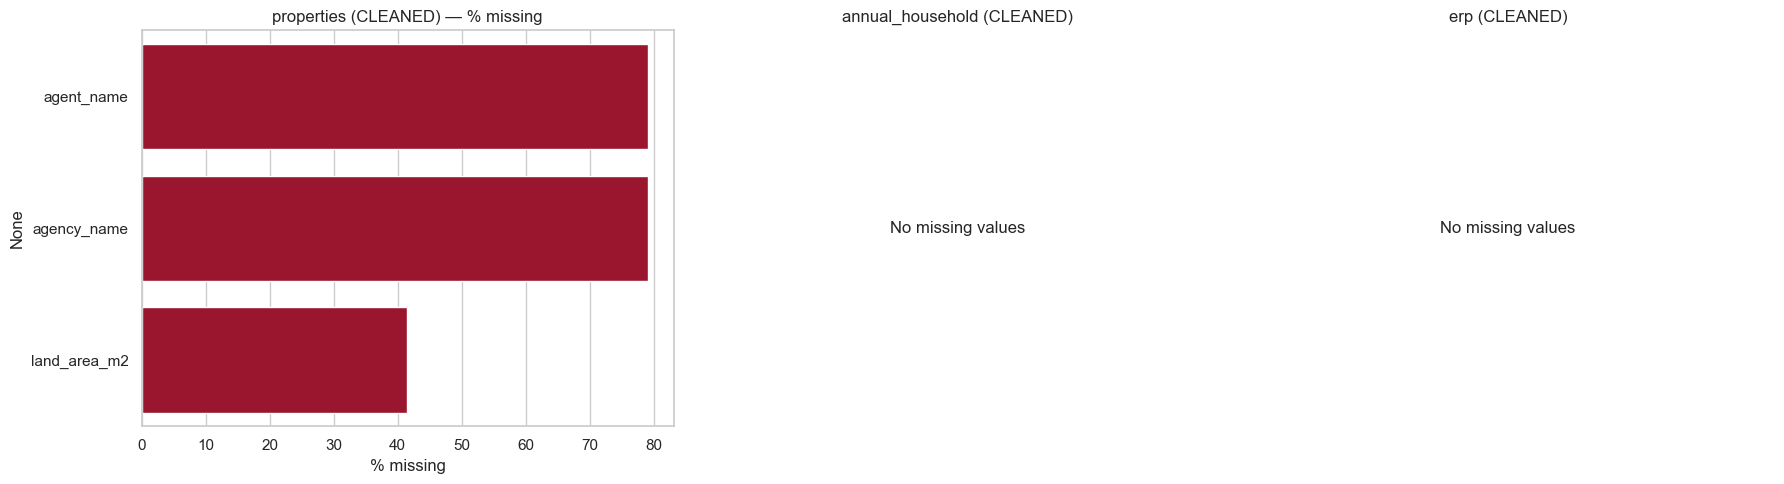


PROPERTIES — CLEANED
Rows: 8,336 | Unique suburbs: 66 | Sale years: 2012–2025


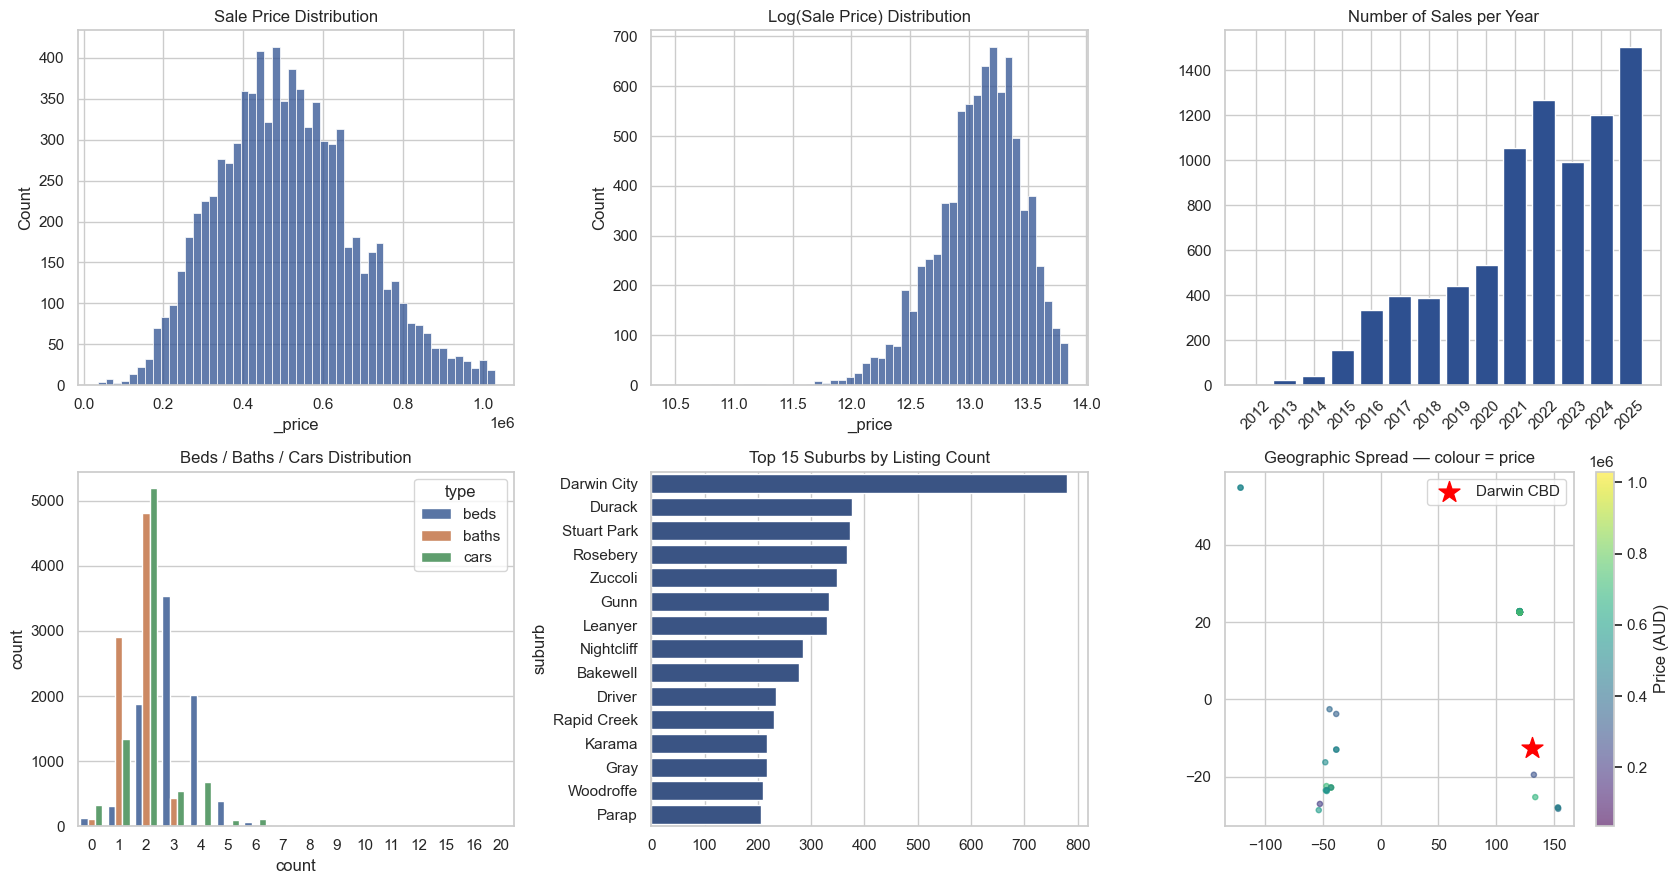

IQR-based price outliers: 71 (0.9%)

ANNUAL HOUSEHOLD INCOME (NT) — CLEANED
Year coverage: 1990–2025 (36 years)


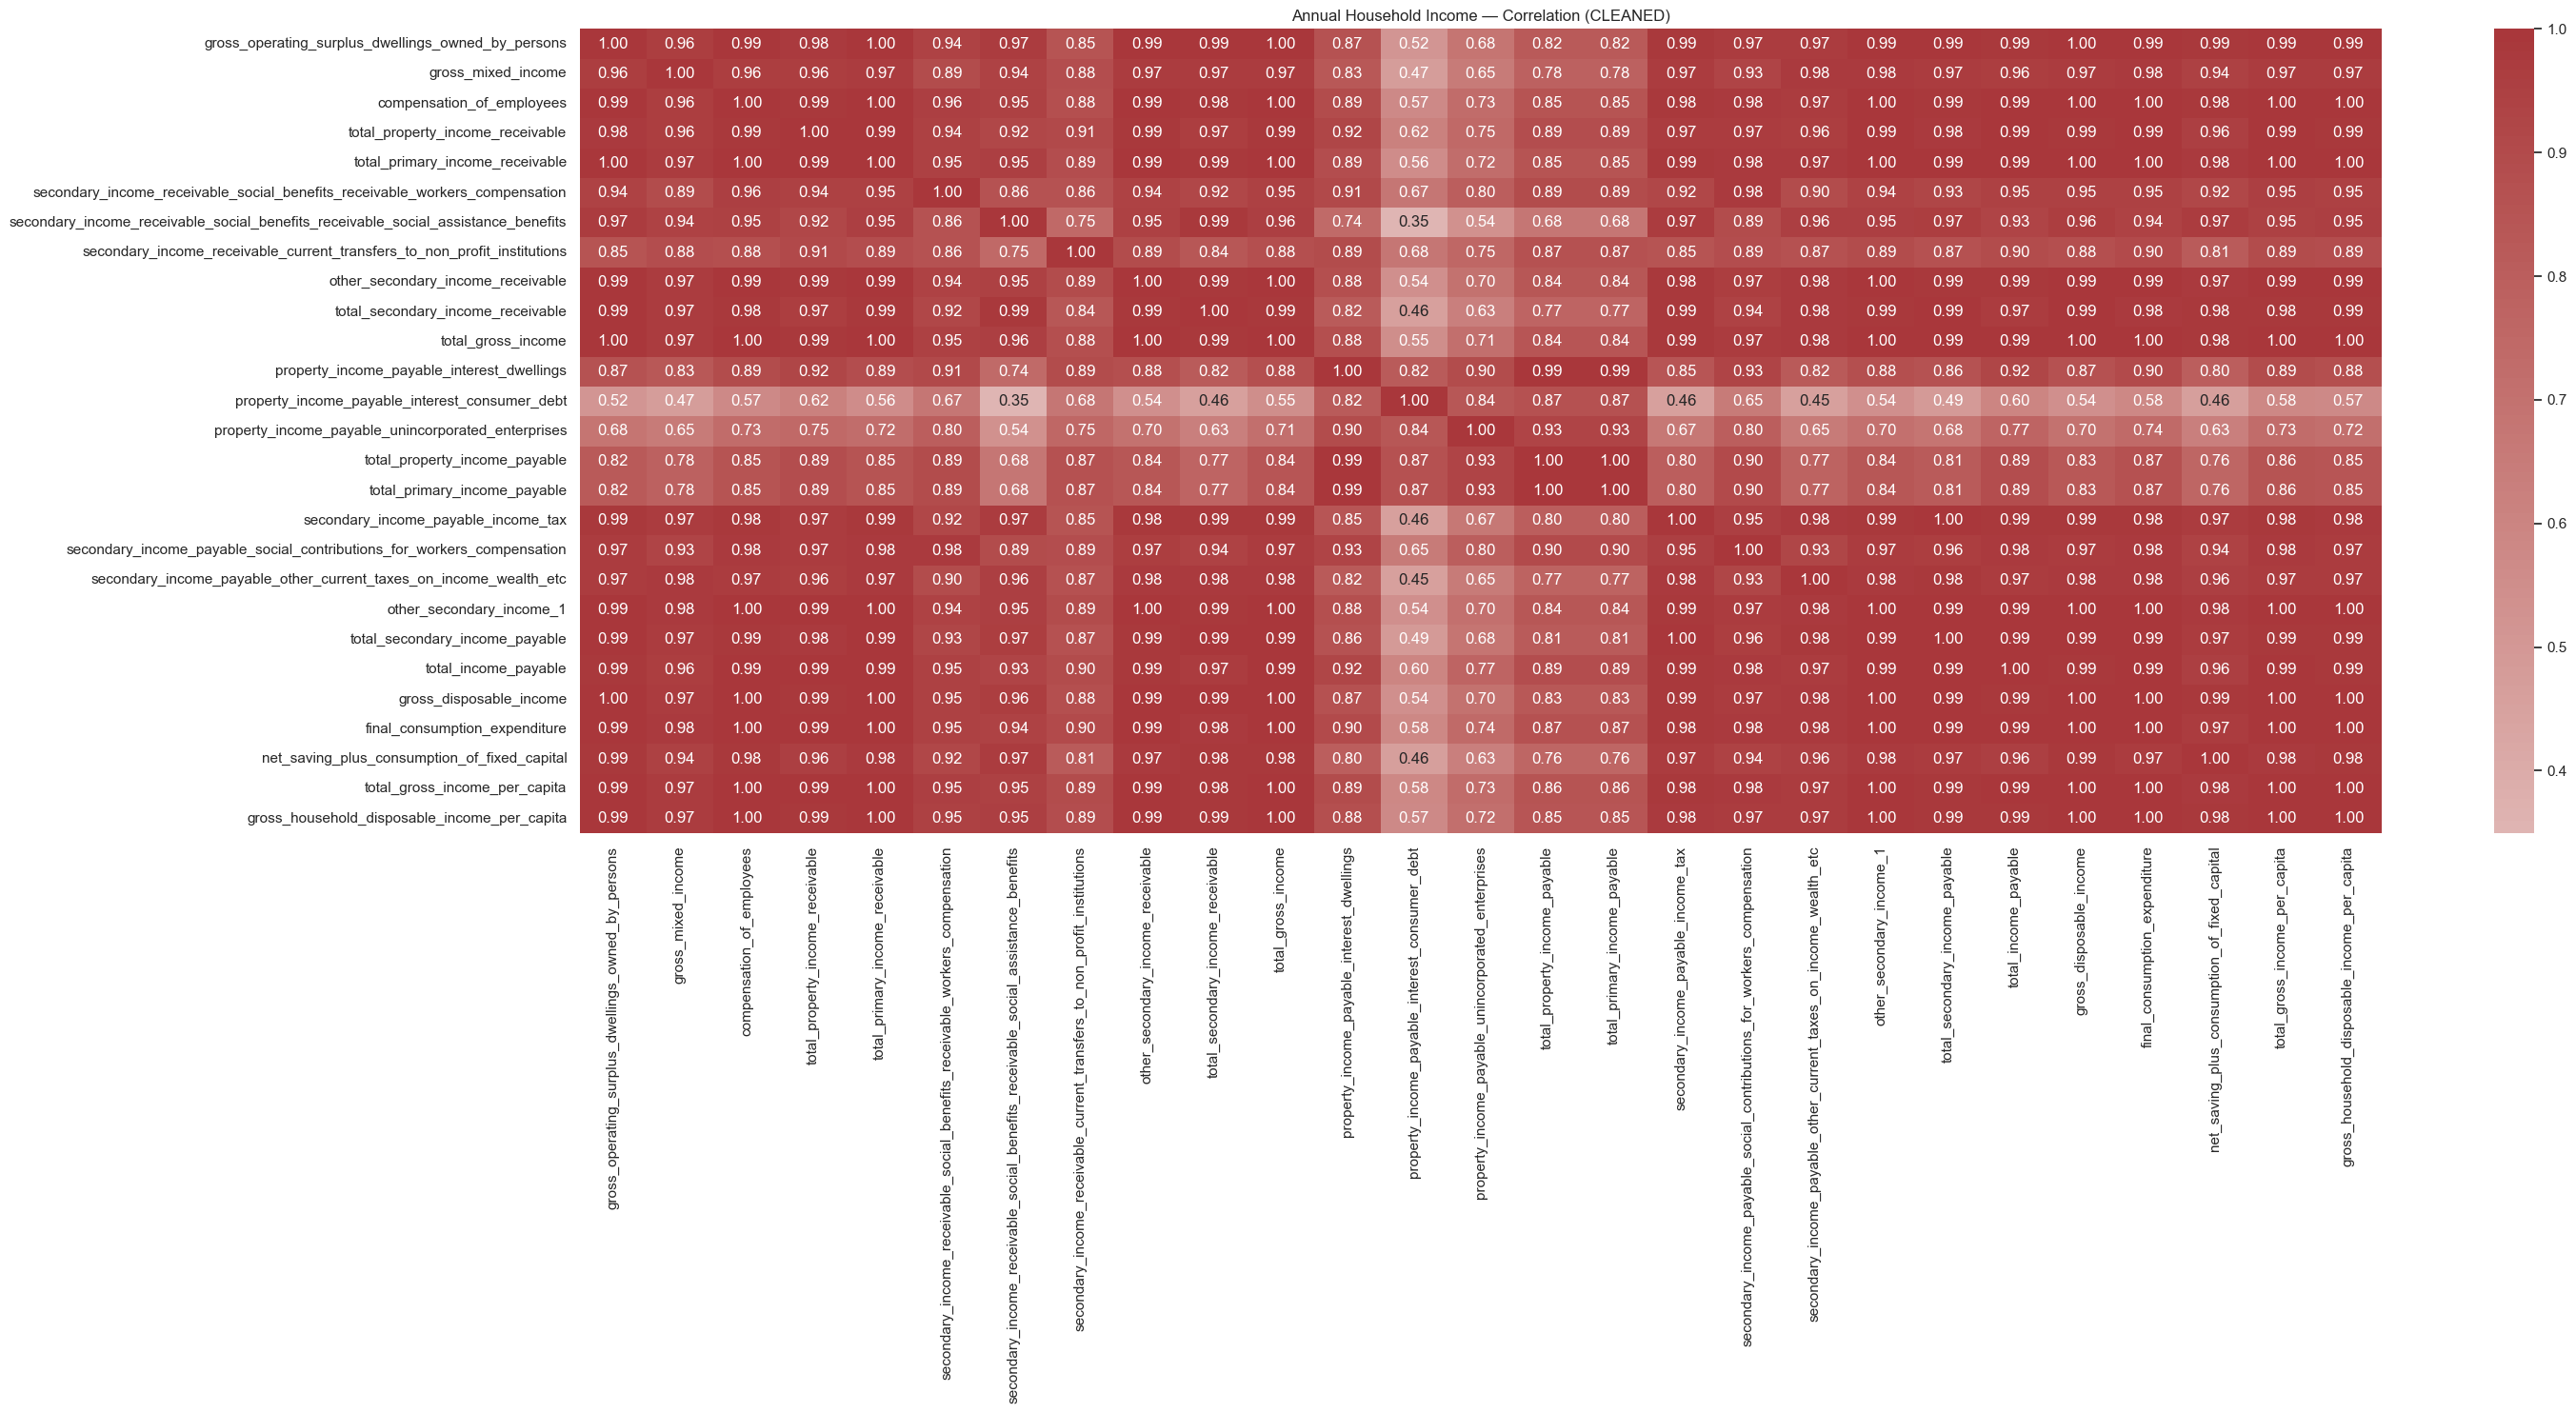

  → INSIGHT [CLEANED]: Indicators ['gross_operating_surplus_dwellings_owned_by_persons', 'gross_mixed_income', 'compensation_of_employees', 'total_property_income_receivable', 'total_primary_income_receivable', 'secondary_income_receivable_social_benefits_receivable_workers_compensation', 'secondary_income_receivable_social_benefits_receivable_social_assistance_benefits', 'other_secondary_income_receivable', 'total_secondary_income_receivable', 'total_gross_income', 'secondary_income_payable_income_tax', 'secondary_income_payable_social_contributions_for_workers_compensation', 'secondary_income_payable_other_current_taxes_on_income_wealth_etc', 'other_secondary_income_1', 'total_secondary_income_payable', 'total_income_payable', 'gross_disposable_income', 'final_consumption_expenditure', 'net_saving_plus_consumption_of_fixed_capital', 'total_gross_income_per_capita', 'gross_household_disposable_income_per_capita'] are highly correlated (>= 0.9) — kept 'total_gross_income' as the repres

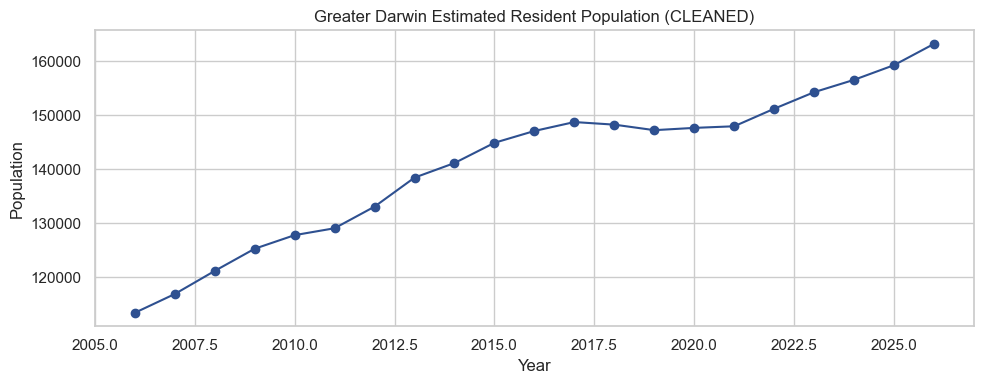


Derived household_features (correlation-clustered, CLEANED stage):
['total_gross_income', 'secondary_income_receivable_current_transfers_to_non_profit_institutions', 'total_property_income_payable', 'property_income_payable_interest_consumer_debt', 'property_income_payable_unincorporated_enterprises']

RBA CASH RATE TARGET — CLEANED
Rate-change events: 98 | Date range: 1990-01-23 to 2026-05-06


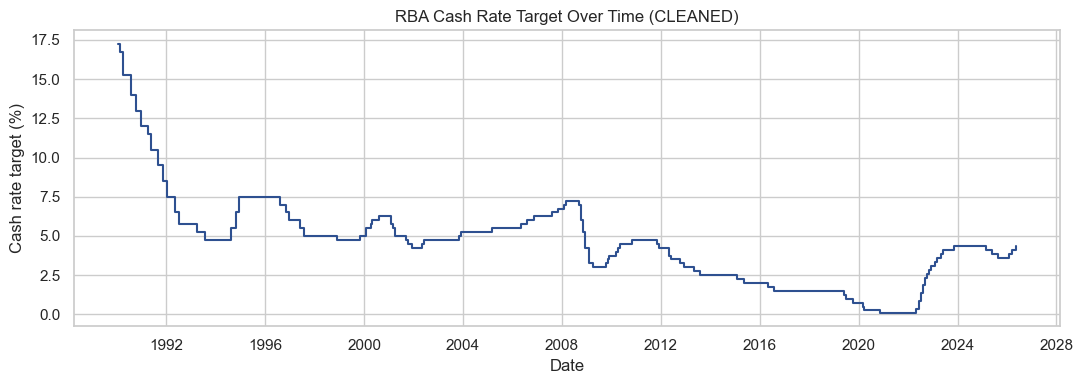

  → INSIGHT [CLEANED]: Year(s) with a single RBA move of >=1.00 percentage point: [1990, 1991, 1992, 1994, 2008, 2009] — these are the sharpest affordability shocks in the series, worth checking against the property test-set years for regime-shift effects.


,date,cash_rate_target,_step_change
0,1990-01-23 00:00:00+00:00,17.25,NaN
1,1990-02-15 00:00:00+00:00,16.75,-0.50
2,1990-04-04 00:00:00+00:00,15.25,-1.50
3,1990-08-02 00:00:00+00:00,14.00,-1.25
4,1990-10-15 00:00:00+00:00,13.00,-1.00
...,...,...,...
93,2025-05-21 00:00:00+00:00,3.85,-0.25
94,2025-08-13 00:00:00+00:00,3.60,-0.25
95,2026-02-04 00:00:00+00:00,3.85,0.25
96,2026-03-18 00:00:00+00:00,4.10,0.25


In [ ]:
household_key_indicators, _ = run_full_eda(properties, annual_household, erp, stage="CLEANED")
print("\nDerived household_features (correlation-clustered, CLEANED stage):")
print(household_key_indicators)

eda_cash_rate_profile(cash_rate, stage="CLEANED")


## 4. Feature Engineering

### 4.1 Distance from Darwin CBD
A simple haversine distance from each property to the city centre.


In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance (in km) between two lat/lon points."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

properties["distance_from_cbd_km"] = haversine_km(
    properties["latitude"], properties["longitude"], DARWIN_CBD_LAT, DARWIN_CBD_LON
)


### 4.2 Sale year / sale month
Pulled straight out of the sale date, so the models can pick up on seasonal or yearly patterns
directly, rather than only indirectly through the macro columns.


In [ ]:
properties["sale_year"] = properties["sold_date_iso"].dt.year
properties["sale_month"] = properties["sold_date_iso"].dt.month


## 4.3 Property Type

`properties.csv` doesn't have a property_type column at all — it's just id / address / url /
status / dates / price / beds / baths / cars / land / coordinates / agent / agency / suburb.
House vs unit vs townhouse should explain a decent chunk of price variance, so it's worth
deriving even though it means trusting a heuristic instead of a real column.

We build it two independent ways, then cross-check them against each other:

1. `property_type_from_address` — parsed from the address text (unit-before-slash patterns,
   "townhouse"/"duplex", "unit"/"apartment"/"flat", "lot"/"vacant land").
2. `has_land_area` — whether `land_area_m2` was ever recorded at all, on the assumption units
   mostly won't have one and houses mostly will.

If the two agree most of the time, we can trust the address-derived label. If they don't, that's
a sign the heuristic isn't reliable.


In [ ]:
import re

UNIT_WORDS = r"unit|apartment|apt|flat"
TOWNHOUSE_WORDS = r"townhouse|town house|duplex"
LAND_WORDS = r"^lot\s|vacant land"


def derive_property_type_from_address(address):
    """Classifies a property from its address text alone. Defaults to "House" when nothing
    matches -- that's the majority case anyway."""
    if pd.isna(address):
        return "Unknown"
    a = str(address).strip().lower()

    # "12/34 Smith Street" -- unit number before a slash, both sides numeric-led
    if re.match(r"^\s*\d+[a-z]?\s*/\s*\d", a):
        return "Unit"
    if re.search(TOWNHOUSE_WORDS, a):
        return "Townhouse"
    if re.search(UNIT_WORDS, a):
        return "Unit"
    if re.search(LAND_WORDS, a):
        return "Vacant Land"
    return "House"


properties["property_type_from_address"] = properties["address"].apply(derive_property_type_from_address)
properties["has_land_area"] = properties["land_area_m2"].notna().map({True: "Has Land Area", False: "No Land Area"})

print("Distribution -- property_type_from_address:")
print(properties["property_type_from_address"].value_counts())
print()

# Cross-check: do the two independent signals actually agree with each other?
crosstab = pd.crosstab(properties["property_type_from_address"], properties["has_land_area"])
print("Cross-check -- address-derived type vs. land-area presence:")
display(crosstab)

house_with_land_pct = (
    crosstab.loc["House", "Has Land Area"] / crosstab.loc["House"].sum() * 100
    if "House" in crosstab.index else float("nan")
)
unit_without_land_pct = (
    crosstab.loc["Unit", "No Land Area"] / crosstab.loc["Unit"].sum() * 100
    if "Unit" in crosstab.index else float("nan")
)
print(f"\n{house_with_land_pct:.0f}% of address-derived Houses HAVE a recorded land area "
      f"(expect this high if the heuristic is reliable).")
print(f"{unit_without_land_pct:.0f}% of address-derived Units have NO recorded land area "
      f"(expect this high if the heuristic is reliable).")

if house_with_land_pct >= 70 and unit_without_land_pct >= 70:
    note("FEATURE-ENGINEERING",
         f"property_type_from_address agrees with has_land_area on the large majority of rows "
         f"({house_with_land_pct:.0f}% / {unit_without_land_pct:.0f}%) -- treating the "
         f"address-derived label as reasonably trustworthy and adding it as a model feature.")
else:
    note("FEATURE-ENGINEERING",
         f"property_type_from_address only agrees with has_land_area on {house_with_land_pct:.0f}%"
         f" / {unit_without_land_pct:.0f}% of rows -- the address-parsing heuristic may be "
         f"unreliable for this dataset; consider using has_land_area alone instead, or manually "
         f"spot-checking a sample of addresses against their assigned type before trusting this "
         f"feature in the report.")


Distribution -- property_type_from_address:
property_type_from_address
House          4959
Unit           3366
Vacant Land      11
Name: count, dtype: int64

Cross-check -- address-derived type vs. land-area presence:


has_land_area,Has Land Area,No Land Area
property_type_from_address,,
House,3454,1505
Unit,1428,1938
Vacant Land,2,9



70% of address-derived Houses HAVE a recorded land area (expect this high if the heuristic is reliable).
58% of address-derived Units have NO recorded land area (expect this high if the heuristic is reliable).
  → INSIGHT [FEATURE-ENGINEERING]: property_type_from_address only agrees with has_land_area on 70% / 58% of rows -- the address-parsing heuristic may be unreliable for this dataset; consider using has_land_area alone instead, or manually spot-checking a sample of addresses against their assigned type before trusting this feature in the report.


## 5. Merging Datasets

`erp` and `annual_household` both merge on `year` alone — no suburb key needed, since every
property is inside Greater Darwin and the household data is NT-wide anyway. `cash_rate` is
different: since it's event-based, it needs a date-based join instead (Section 5.1).


In [ ]:
# --- Merge ERP (year only -- Greater Darwin-wide, no suburb key needed since every
#     property here is located within Greater Darwin) ---
merged = properties.merge(
    erp.rename(columns={"year": "erp_year", "population": "erp_population"}),
    left_on="sale_year", right_on="erp_year", how="left"
)

# --- Merge annual_household (year only -- NT-wide, no suburb key) ---
merged = merged.merge(
    annual_household, left_on="sale_year", right_on="year", how="left", suffixes=("", "_nt")
)

print(f"ERP population match rate: {merged['erp_population'].notna().mean()*100:.1f}% "
      f"(should be ~100% — continuous year-only join, every sale is within Greater Darwin)")
print(f"Annual household match rate: {merged['total_gross_income'].notna().mean()*100:.1f}% "
      f"(should be ~100% since it's a continuous year-only join)")


ERP population match rate: 100.0% (should be ~100% — continuous year-only join, every sale is within Greater Darwin)
Annual household match rate: 100.0% (should be ~100% since it's a continuous year-only join)


### 5.1 Merging the RBA Cash Rate

Can't merge this on `year` since it's event-based — instead, each sale gets the cash rate that
was actually in effect on its sale date, using `merge_asof`. Two things come out of this:

- `cash_rate_target` — the rate level at the time of sale.
- `cash_rate_change_12m` — how much it moved in the 12 months before the sale, i.e. how fast
  things were tightening or easing, not just where the level sat.

Both are publicly known at the time of each sale, so there's no leakage risk doing this before
the train/test split.


In [ ]:
merged = merged.sort_values("sold_date_iso")

# --- Cash rate AT the sale date (most recent RBA change on or before that date) ---
merged = pd.merge_asof(
    merged, cash_rate, left_on="sold_date_iso", right_on="date", direction="backward"
).drop(columns=["date"])

# --- Cash rate 12 months BEFORE the sale date, to work out the recent pace of change ---
cash_rate_12m_ago = cash_rate.rename(
    columns={"date": "date_12m_ago", "cash_rate_target": "cash_rate_target_12m_ago"}
).sort_values("date_12m_ago")

merged["_date_12m_ago"] = merged["sold_date_iso"] - pd.DateOffset(months=12)
merged = merged.sort_values("_date_12m_ago")
merged = pd.merge_asof(
    merged, cash_rate_12m_ago, left_on="_date_12m_ago", right_on="date_12m_ago",
    direction="backward"
).drop(columns=["date_12m_ago", "_date_12m_ago"])

merged["cash_rate_change_12m"] = merged["cash_rate_target"] - merged["cash_rate_target_12m_ago"]
merged = merged.drop(columns=["cash_rate_target_12m_ago"])
merged = merged.sort_values("sold_date_iso").reset_index(drop=True)

print(f"Cash rate match rate: {merged['cash_rate_target'].notna().mean()*100:.1f}% "
      f"(should be ~100% -- the RBA series starts in 1990, well before any property sale here)")

merged.to_csv(PROCESSED_DIR / "merged_raw.csv", index=False)
print(f"Merged shape: {merged.shape}")


Cash rate match rate: 100.0% (should be ~100% -- the RBA series starts in 1990, well before any property sale here)
Merged shape: (8336, 58)


### 5.2 Year-Coverage Check

Since `annual_household` is now a real multi-year series (not a single snapshot), every sale
year should find a match automatically. This cell just confirms that's actually true.


In [ ]:
unmatched_years = merged.loc[merged["total_gross_income"].isna(), "sale_year"].unique()
if len(unmatched_years):
    note("POST-MERGE", f"Sale year(s) with no annual_household match: {unmatched_years} ")
else:
    print("Every sale year matched the annual household series exactly \u2014 no gap-filling needed.")


Every sale year matched the annual household series exactly — no gap-filling needed.


### 5.3 Model-Ready Frame — Row Filtering Only

Only dropping rows with no known `price_numeric` here, since a row with no target is useless
either way. Everything else stays as `NaN` for now.

Why wait? Filling missing values using a median from the *whole* dataset would let information
from the test set leak into the training values. So imputation waits until after the split
(Section 7), using training-only statistics.


In [ ]:
model_df = merged.dropna(subset=["price_numeric"]).copy()

# household_features comes directly from the correlation-clustering pass above (Section 2.3)
household_features = [c for c in (household_key_indicators or []) if c in model_df.columns]
if not household_features:
    raise RuntimeError(
        "household_key_indicators is empty/None -- check that the CLEANED-stage run_full_eda "
        "call ran successfully and that 'year' was parsed on annual_household before that call."
    )

# Note: "price_per_sqm" is NOT a model feature -- it's literally price_numeric / land_area_m2,
# so including it would let the model reconstruct the target from itself.
numeric_candidates = [
    "beds", "baths", "cars", "land_area_m2", "distance_from_cbd_km",
    "latitude", "longitude", "erp_population", "sale_year", "sale_month",
    "cash_rate_target", "cash_rate_change_12m",
] + household_features
numeric_candidates = [c for c in numeric_candidates if c in model_df.columns]

for col in numeric_candidates:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

missing_summary = model_df[numeric_candidates].isna().sum()
missing_summary = missing_summary[missing_summary > 0]
print("Numeric features retained for modelling:", numeric_candidates)
print(f"Rows with a known price: {model_df.shape[0]:,} | columns: {model_df.shape[1]}")
if len(missing_summary):
    print("\nMissing values remain in these features (left as-is on purpose — imputed AFTER "
          "the temporal split in Section 7, using train-only statistics):")
    print(missing_summary)
else:
    print("\nNo missing values in the retained numeric features.")


Numeric features retained for modelling: ['beds', 'baths', 'cars', 'land_area_m2', 'distance_from_cbd_km', 'latitude', 'longitude', 'erp_population', 'sale_year', 'sale_month', 'cash_rate_target', 'cash_rate_change_12m', 'total_gross_income', 'secondary_income_receivable_current_transfers_to_non_profit_institutions', 'total_property_income_payable', 'property_income_payable_interest_consumer_debt', 'property_income_payable_unincorporated_enterprises']
Rows with a known price: 8,336 | columns: 58

Missing values remain in these features (left as-is on purpose — imputed AFTER the temporal split in Section 7, using train-only statistics):
land_area_m2    3452
dtype: int64


## 6. Temporal Train/Test Split

This is a forecasting problem, so the split has to be by time — train on the earlier sales, test
on the most recent ones. A random split would let the model see pricing patterns from sales that
happened *after* the ones it's being tested on — that's leakage.

Everything from here on (imputation stats, scaler, encoders, suburb encoding) gets fit on
`train_df` only, then applied unchanged to `test_df`.


In [ ]:
model_df = model_df.sort_values("sold_date_iso").reset_index(drop=True)
# Use the 80th percentile sale date as the cutoff: earlier sales -> train, later -> test
cutoff = model_df["sold_date_iso"].quantile(0.8)
train_df = model_df[model_df["sold_date_iso"] <= cutoff].copy()
test_df = model_df[model_df["sold_date_iso"] > cutoff].copy()

print(f"Temporal cutoff: {cutoff.date()}")
print(f"Train: {len(train_df):,} rows ({train_df['sold_date_iso'].min().date()} to {train_df['sold_date_iso'].max().date()})")
print(f"Test:  {len(test_df):,} rows ({test_df['sold_date_iso'].min().date()} to {test_df['sold_date_iso'].max().date()})")


Temporal cutoff: 2024-11-14
Train: 6,674 rows (2012-08-14 to 2024-11-14)
Test:  1,662 rows (2024-11-15 to 2025-12-31)


## 7. Imputation — Train-Only Statistics

Same rule as the split above: any statistic used to fill a gap is learned from `train_df` only,
then applied to both splits unchanged. `land_area_m2` is the one exception — it gets a k-NN fill
instead of a flat median (Section 7.1). Everything else uses the training median.


In [ ]:
def fit_impute_stats(df, numeric_cols):
    """Learns fill-in values from df -- this MUST be the TRAINING split only.
    land_area_m2 is skipped here on purpose -- Section 7.1 fills it with a k-NN model
    (location + beds) instead of a single median."""
    stats = {}
    for col in numeric_cols:
        if col == "land_area_m2":
            continue
        stats[col] = {"global": df[col].median()}
    return stats


def apply_impute_stats(df, numeric_cols, stats):
    """Fills missing values using PRE-FITTED statistics -- never recomputes from df itself."""
    df = df.copy()
    for col in numeric_cols:
        if col == "land_area_m2" or col not in df.columns or df[col].isna().sum() == 0:
            continue
        df[col] = df[col].fillna(stats[col]["global"])
    return df


impute_stats = fit_impute_stats(train_df, numeric_candidates)          # fit on TRAIN ONLY
train_df = apply_impute_stats(train_df, numeric_candidates, impute_stats)
test_df = apply_impute_stats(test_df, numeric_candidates, impute_stats)  # same stats, no re-fit

for name, d in [("train", train_df), ("test", test_df)]:
    remaining_cols = [c for c in numeric_candidates if c != "land_area_m2"]
    remaining = int(d[remaining_cols].isna().sum().sum())
    status = "clean" if remaining == 0 else f"{remaining} missing value(s) still remain"
    print(f"{name}_df after imputation (excl. land_area_m2, handled in Section 7.1): {status}")


train_df after imputation (excl. land_area_m2, handled in Section 7.1): clean
test_df after imputation (excl. land_area_m2, handled in Section 7.1): clean


## 7.1 land_area_m2 — k-NN Instead of a Flat Median

A single city-wide median for land area would ignore how much block size varies between Darwin
suburbs — wrong for both a CBD unit and a rural-fringe block. Instead, we fill each gap using
similar nearby properties (by location and bed count), which keeps that variation.


In [ ]:
from sklearn.impute import KNNImputer

LAND_AREA_PREDICTORS = [c for c in ["beds", "baths", "cars"] if c in train_df.columns]
LAND_AREA_KNN_K = 7


def fit_land_area_imputer(df, predictors=LAND_AREA_PREDICTORS, k=LAND_AREA_KNN_K):
    """Fits a k-NN imputer for land_area_m2 using beds/baths/cars as predictors -- this MUST be
    the TRAINING split only. Predictors are standardised first so distance isn't dominated by
    whichever column has the largest raw scale."""
    scaler = StandardScaler().fit(df[predictors])
    scaled_predictors = scaler.transform(df[predictors])
    combined = np.column_stack([scaled_predictors, df["land_area_m2"].values])
    imputer = KNNImputer(n_neighbors=k, weights="distance")
    imputer.fit(combined)
    return {
        "scaler": scaler, "imputer": imputer, "predictors": predictors,
        "fallback_median": df["land_area_m2"].median(),
    }


def apply_land_area_imputer(df, stats):
    """Fills land_area_m2 using the PRE-FITTED k-NN imputer -- never re-fit on df itself."""
    df = df.copy()
    scaled_predictors = stats["scaler"].transform(df[stats["predictors"]])
    combined = np.column_stack([scaled_predictors, df["land_area_m2"].values])
    filled = stats["imputer"].transform(combined)[:, -1]
    df["land_area_m2"] = filled
    df["land_area_m2"] = df["land_area_m2"].fillna(stats["fallback_median"])  # last-resort only
    return df


land_area_stats = fit_land_area_imputer(train_df)            # fit on TRAIN ONLY
train_df = apply_land_area_imputer(train_df, land_area_stats)
test_df = apply_land_area_imputer(test_df, land_area_stats)   # same fitted k-NN, no re-fit

for name, d in [("train", train_df), ("test", test_df)]:
    remaining = int(d["land_area_m2"].isna().sum())
    status = "clean" if remaining == 0 else f"{remaining} missing value(s) still remain"
    print(f"{name}_df land_area_m2 after k-NN imputation: {status}")

model_df = pd.concat([train_df, test_df]).sort_values("sold_date_iso").reset_index(drop=True)


train_df land_area_m2 after k-NN imputation: clean
test_df land_area_m2 after k-NN imputation: clean


## 7.2 Suburb Bucketing — Rare Suburbs → "Other"

`suburb` goes into a one-hot encoder. A suburb with only a handful of training sales would get
its own column estimated from almost nothing — mainly a problem for Linear Regression's
stability (tree models handle it more gracefully). The "common enough" threshold is learned from
`train_df` only, then applied to `test_df` unchanged.


In [ ]:
SUBURB_MIN_COUNT = 10  # suburbs with fewer than this many TRAINING sales get bucketed into "Other"

suburb_counts = train_df["suburb"].value_counts()
common_suburbs = set(suburb_counts[suburb_counts >= SUBURB_MIN_COUNT].index)

def bucket_suburb(s):
    """Keeps common suburbs as-is; groups rare ones into "Other"."""
    return s if s in common_suburbs else "Other"

train_df["suburb"] = train_df["suburb"].apply(bucket_suburb)
test_df["suburb"] = test_df["suburb"].apply(bucket_suburb)
model_df["suburb"] = model_df["suburb"].apply(bucket_suburb)

n_bucketed_train = int((train_df["suburb"] == "Other").sum())
n_bucketed_test = int((test_df["suburb"] == "Other").sum())
print(f"Suburb cardinality before bucketing: {len(suburb_counts)} distinct suburbs in train_df")
print(f"Kept {len(common_suburbs)} suburbs with >= {SUBURB_MIN_COUNT} training sales; "
      f"bucketed the rest into 'Other' ({n_bucketed_train} train rows, {n_bucketed_test} test rows).")


Suburb cardinality before bucketing: 66 distinct suburbs in train_df
Kept 48 suburbs with >= 10 training sales; bucketed the rest into 'Other' (76 train rows, 14 test rows).


## 7.3 Suburb Target Encoding

Bucketing rare suburbs into "Other" throws away real location signal that tree models could
otherwise use directly. This adds a numeric feature instead: `suburb_target_enc`, each suburb's
smoothed mean price. It's recency-weighted, so an older sale counts for less than a recent one —
the encoded value reflects where a suburb sits *now*, not a flat 16-year average. Fit on
`train_df` only, same as everything else here.


In [ ]:
SUBURB_ENCODING_SMOOTHING = 10       # weight, in "pseudo-sales", given to the global mean
SUBURB_ENCODING_HALF_LIFE_YEARS = 2  # a sale this many years before the training cutoff counts
                                       # for half as much as a sale made on the cutoff date itself


def fit_suburb_target_encoding(df, target_col="price_numeric", date_col="sold_date_iso",
                                m=SUBURB_ENCODING_SMOOTHING,
                                half_life_years=SUBURB_ENCODING_HALF_LIFE_YEARS):
    """Fit on TRAINING rows only, using 'suburb_raw' (before bucketing). Each row's weight
    decays with age -- half_life_years back and it counts half as much -- so a suburb's encoded
    value reflects where it sits now. Suburbs with thin sales history still get pulled toward
    the (also recency-weighted) global mean."""
    cutoff = df[date_col].max()
    years_before_cutoff = (cutoff - df[date_col]).dt.days / 365
    weight = 0.5 ** (years_before_cutoff / half_life_years)

    d = df[["suburb_raw", target_col]].copy()
    d["_weight"] = weight
    d["_weighted_target"] = d[target_col] * d["_weight"]

    global_mean = d["_weighted_target"].sum() / d["_weight"].sum()

    grouped = d.groupby("suburb_raw").agg(
        weight_sum=("_weight", "sum"),
        weighted_sum=("_weighted_target", "sum"),
    )
    grouped["suburb_mean"] = grouped["weighted_sum"] / grouped["weight_sum"]
    smoothed = (
        (grouped["weight_sum"] * grouped["suburb_mean"] + m * global_mean)
        / (grouped["weight_sum"] + m)
    )
    return {"map": smoothed, "global_mean": global_mean, "cutoff": cutoff,
            "half_life_years": half_life_years}


def apply_suburb_target_encoding(df, stats):
    """Maps the PRE-FITTED recency-weighted suburb means onto df -- never recomputed from df
    itself. Suburbs unseen in training fall back to the training global weighted mean."""
    df = df.copy()
    df["suburb_target_enc"] = df["suburb_raw"].map(stats["map"]).fillna(stats["global_mean"])
    return df


suburb_encoding_stats = fit_suburb_target_encoding(train_df)             # fit on TRAIN ONLY
train_df = apply_suburb_target_encoding(train_df, suburb_encoding_stats)
test_df = apply_suburb_target_encoding(test_df, suburb_encoding_stats)    # same map, no re-fit
model_df = apply_suburb_target_encoding(model_df, suburb_encoding_stats)  # for consistent reporting

if "suburb_target_enc" not in numeric_candidates:
    numeric_candidates.append("suburb_target_enc")

n_unseen_test = int((~test_df["suburb_raw"].isin(suburb_encoding_stats["map"].index)).sum())
print(f"Suburb target encoding fit on {len(suburb_encoding_stats['map'])} training suburbs "
      f"(smoothing m={SUBURB_ENCODING_SMOOTHING}, recency half-life="
      f"{SUBURB_ENCODING_HALF_LIFE_YEARS}y, cutoff={suburb_encoding_stats['cutoff'].date()}); "
      f"{n_unseen_test} test row(s) fell back to the training global mean (suburb unseen in "
      f"training).")


Suburb target encoding fit on 66 training suburbs (smoothing m=10, recency half-life=2y, cutoff=2024-11-14); 0 test row(s) fell back to the training global mean (suburb unseen in training).


## 8. Feature Engineering (Post-Imputation)

`price_per_sqm` is computed here now that `land_area_m2` is fully filled in — but purely for
reporting. It's literally `price / land_area_m2`, so using it as a predictor would let the model
reconstruct the target from itself. It's never added to the feature list.


In [ ]:
train_df["price_per_sqm"] = train_df["price_numeric"] / train_df["land_area_m2"]
test_df["price_per_sqm"] = test_df["price_numeric"] / test_df["land_area_m2"]
model_df["price_per_sqm"] = model_df["price_numeric"] / model_df["land_area_m2"]

model_df.to_csv(MODEL_READY_DIR / "model_ready.csv", index=False)
model_df[["distance_from_cbd_km", "price_per_sqm", "sale_year", "sale_month"]].describe().T


,count,mean,std,min,25%,50%,75%,max
distance_from_cbd_km,8336.0,74.266122,786.168009,0.013135,7.459819,11.023960,15.76168,18262.529709
price_per_sqm,8336.0,1440.612162,7659.174152,35.971223,715.064024,972.222222,1597.66286,430000.000000
sale_year,8336.0,2021.673704,2.812443,2012.000000,2020.000000,2022.000000,2024.00000,2025.000000
sale_month,8336.0,6.843210,3.328380,1.000000,4.000000,7.000000,10.00000,12.000000


## 9. EDA Pass 3 — Post-Merge, Correlation With Target

Now that every engineered/merged feature sits next to `price_numeric`, we can see which ones are
actually worth keeping. This runs on `train_df` only — letting feature decisions be shaped by
patterns in the test set would be a subtler form of the same leakage the split was meant to
prevent.


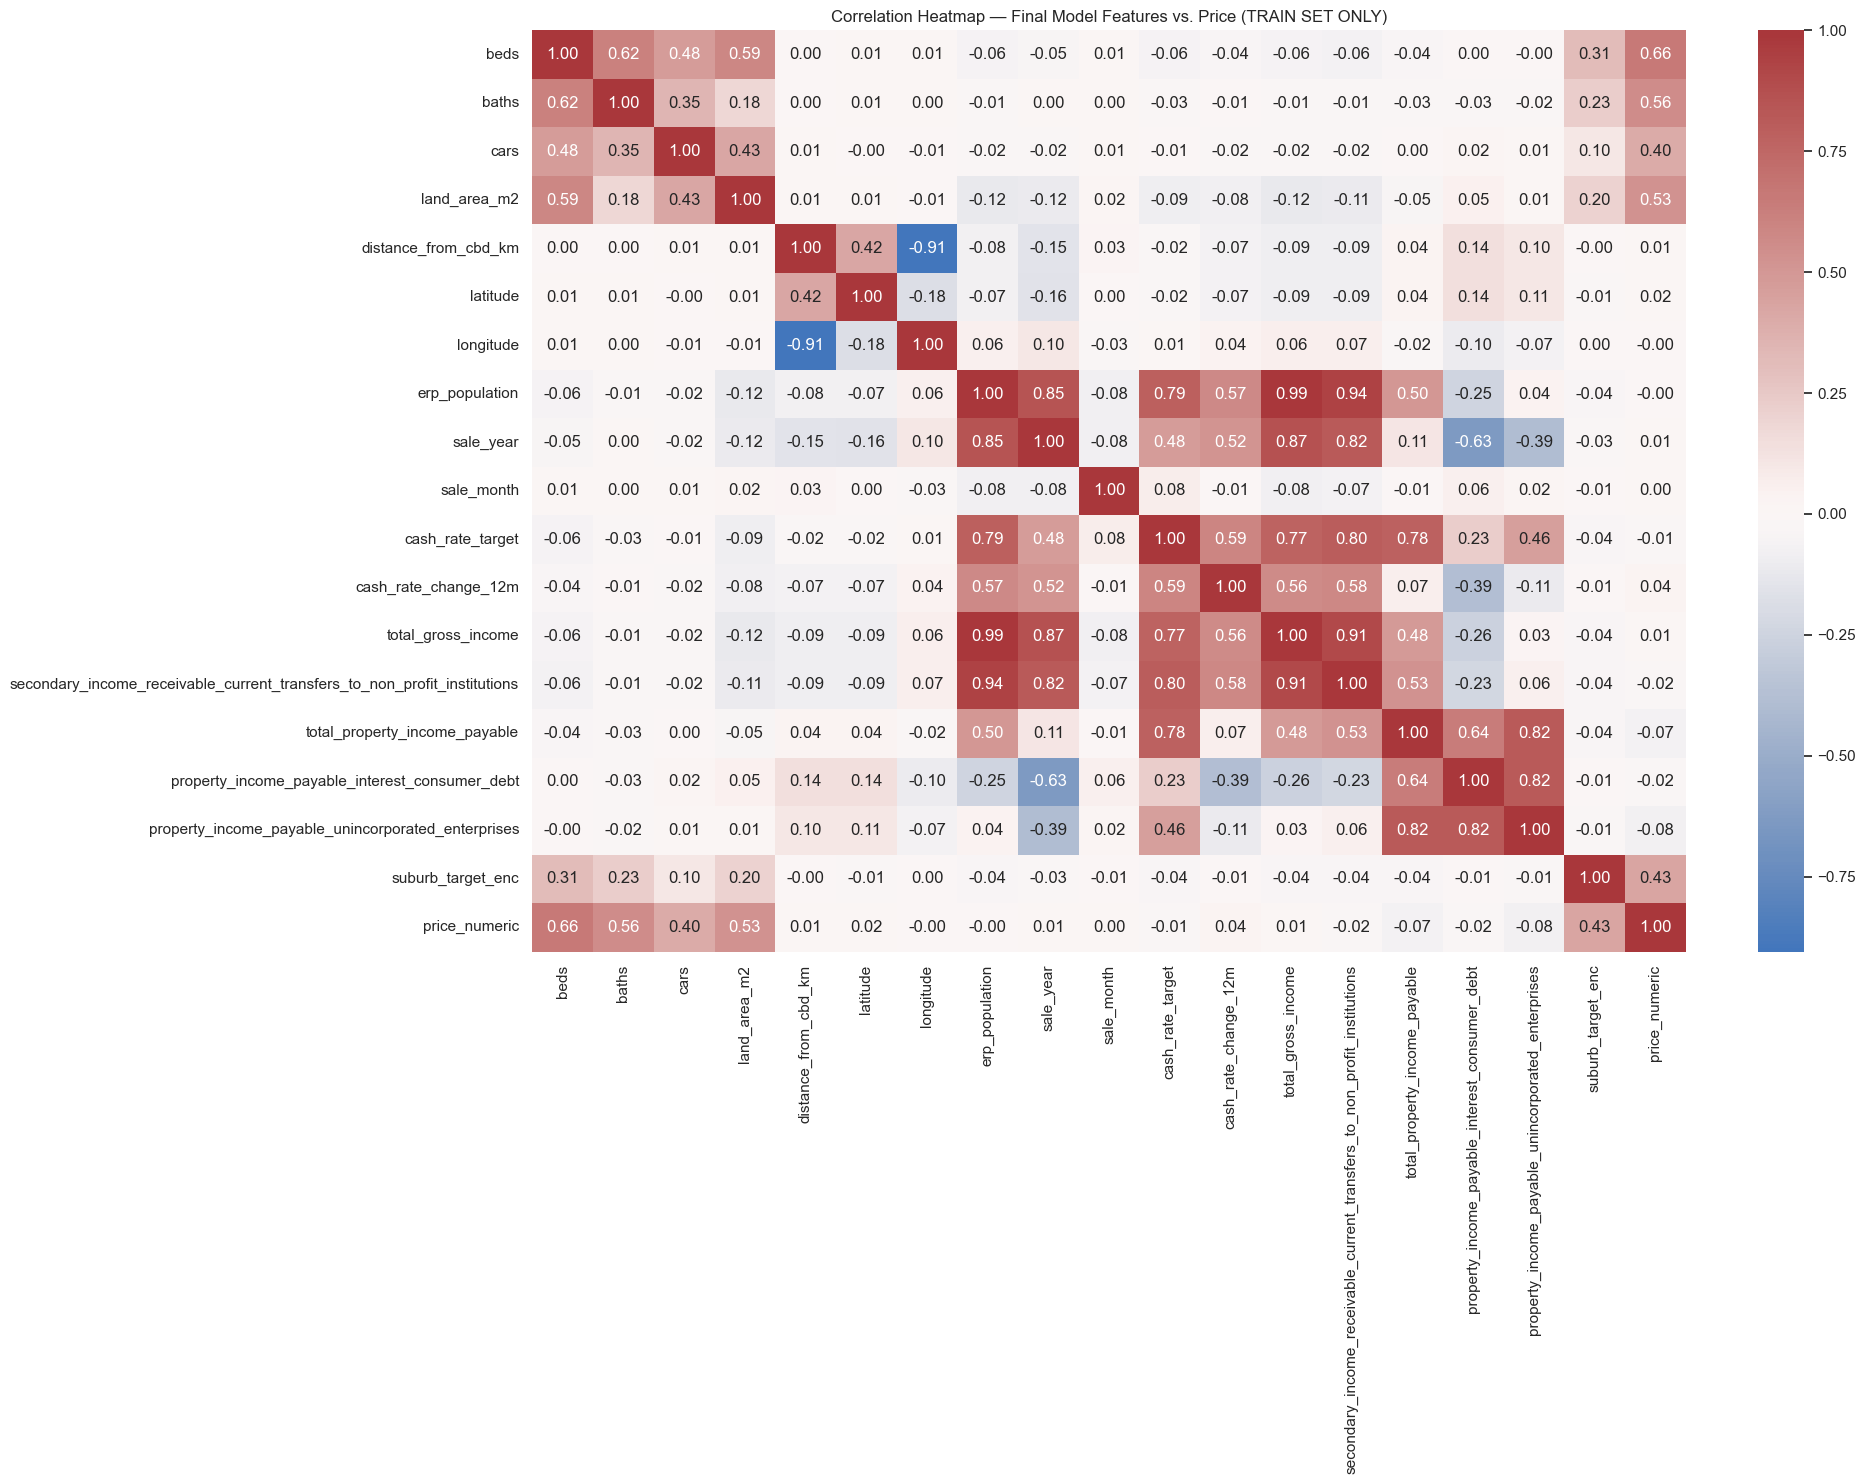

Features ranked by |correlation| with price_numeric (train set):
beds                                                                        0.660435
baths                                                                       0.559606
land_area_m2                                                                0.528936
suburb_target_enc                                                           0.433416
cars                                                                        0.402293
property_income_payable_unincorporated_enterprises                         -0.078864
total_property_income_payable                                              -0.071245
cash_rate_change_12m                                                        0.038772
property_income_payable_interest_consumer_debt                             -0.019944
secondary_income_receivable_current_transfers_to_non_profit_institutions   -0.018500
latitude                                                                    0.016729


In [ ]:
corr_cols = numeric_candidates + ["price_numeric"]
corr_matrix = train_df[corr_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Heatmap — Final Model Features vs. Price (TRAIN SET ONLY)")
plt.tight_layout()
plt.show()

price_corr = corr_matrix["price_numeric"].drop("price_numeric").sort_values(key=abs, ascending=False)
print("Features ranked by |correlation| with price_numeric (train set):")
print(price_corr)

# Flag the weakest and strongest linear relationships with price
for feat, corr_val in price_corr.items():
    if abs(corr_val) < 0.05:
        note("POST-MERGE", f"'{feat}' has near-zero linear correlation with price ({corr_val:.2f}) "
                            f"— unlikely to help Linear Regression; tree models may still use it "
                            f"via non-linear splits.")
    elif abs(corr_val) > 0.4:
        note("POST-MERGE", f"'{feat}' correlates strongly with price ({corr_val:.2f}) — a key "
                            f"driver worth highlighting in the report.")


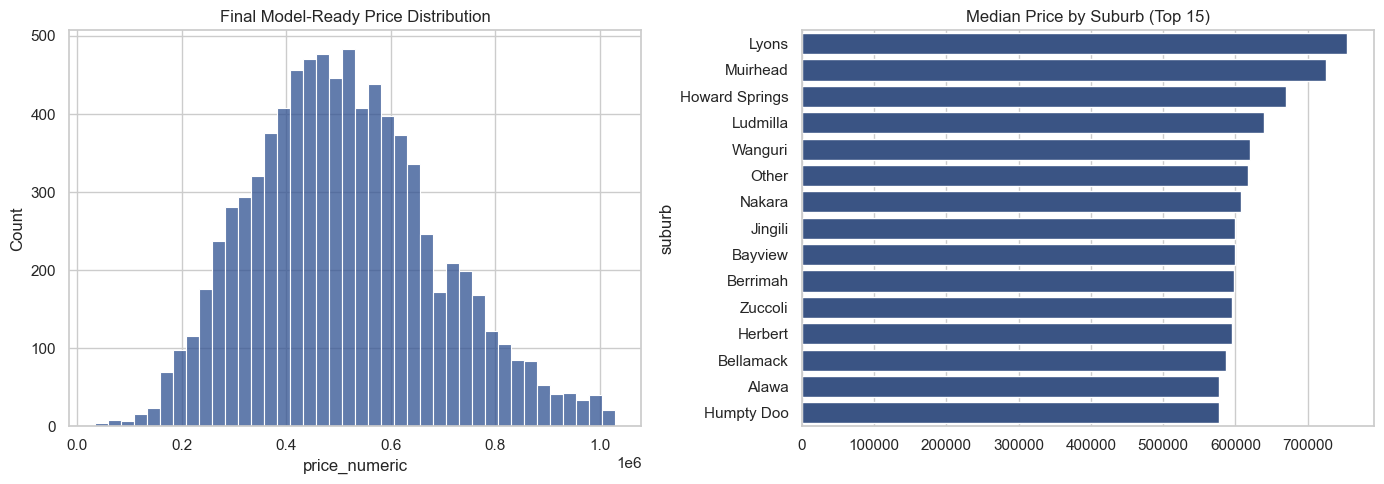

In [ ]:
# Target distribution + top suburbs by median price (descriptive summary of the full dataset)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(model_df["price_numeric"], bins=40, ax=axes[0], color="#2E5090")
axes[0].set_title("Final Model-Ready Price Distribution")

top_suburbs_price = model_df.groupby("suburb")["price_numeric"].median().sort_values(ascending=False).head(15)
sns.barplot(x=top_suburbs_price.values, y=top_suburbs_price.index, ax=axes[1], color="#2E5090")
axes[1].set_title("Median Price by Suburb (Top 15)")
plt.tight_layout()
plt.show()


## 10. Preprocessing Pipeline

`train_df`/`test_df` already exist and are already imputed. This just picks the feature columns
and sets up scaling + one-hot encoding. Both are fit inside `Pipeline.fit()` on `X_train` only,
and just applied (`.transform()`) to `X_test`.


In [ ]:
TARGET = "price_numeric"
# property_type_from_address (Section 4.3) joins suburb as a one-hot encoded feature
categorical_features = ["suburb", "property_type_from_address"]
feature_cols = numeric_candidates + categorical_features

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_candidates),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])


## 10.1 Hyperparameter Tuning

`RandomizedSearchCV` normally uses plain k-fold CV, which would let "future" rows validate
"past" rows — the same kind of leakage the train/test split exists to prevent, just one level
down. `TimeSeriesSplit` keeps every validation fold strictly after its training fold, so tuning
stays honest about how the model will actually be used: predicting forward from what's already
happened.

The XGBoost search space was widened after an earlier pass came back with XGBoost losing to
Random Forest — usually a sign the search space only let it get bigger, not more conservative.
Regularisation knobs (`reg_alpha`, `reg_lambda`, `gamma`, `min_child_weight`) were added so the
search can trade off overfitting risk, not just tree size.


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

rf_param_dist = {
    "model__regressor__n_estimators": [200, 300, 400, 600],
    "model__regressor__max_depth": [None, 8, 12, 20],
    "model__regressor__min_samples_leaf": [1, 2, 4, 8],
    "model__regressor__max_features": ["sqrt", 0.5, 1.0],
}

# Widened XGBoost search space (see markdown above for why)
xgb_param_dist = {
    "model__regressor__n_estimators": [200, 300, 400, 600],
    "model__regressor__max_depth": [3, 4, 5, 6, 8],
    "model__regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__regressor__subsample": [0.7, 0.85, 1.0],
    "model__regressor__colsample_bytree": [0.7, 0.85, 1.0],
    "model__regressor__reg_alpha": [0, 0.01, 0.1, 1, 5],
    "model__regressor__reg_lambda": [1, 1.5, 2, 5, 10],
    "model__regressor__gamma": [0, 0.1, 0.5, 1, 3],
    "model__regressor__min_child_weight": [1, 3, 5, 10],
}

def tune(base_regressor, param_dist, name, n_iter=20):
    """Wraps base_regressor in a log1p/expm1 TransformedTargetRegressor (see Section 11), builds
    the full preprocessing + model pipeline, and searches param_dist with TimeSeriesSplit CV."""
    ttr = TransformedTargetRegressor(regressor=base_regressor, func=np.log1p, inverse_func=np.expm1)
    pipeline = Pipeline([("prep", preprocessor), ("model", ttr)])
    search = RandomizedSearchCV(
        pipeline, param_dist, n_iter=n_iter, cv=tscv,
        scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    print(f"{name} best params: {search.best_params_}")
    print(f"{name} best CV RMSE: {-search.best_score_:.2f}")
    return search.best_params_

rf_best_params = tune(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), rf_param_dist, "Random Forest"
)
xgb_best_params = tune(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1), xgb_param_dist, "XGBoost", n_iter=40
)


## 11. Model Training & Evaluation

Three models: Linear Regression as an interpretable baseline, plus Random Forest and XGBoost for
the non-linear relationships the correlation heatmap can't show. We report RMSE, MAE, and R² on
the held-out test set.

All three train on `log1p(price_numeric)` — the earlier EDA plots showed that's the well-behaved
distribution — wrapped in `TransformedTargetRegressor` so every metric and plot below is still
reported on the original AUD scale. Random Forest and XGBoost use the tuned hyperparameters from
Section 10.1 rather than defaults.


In [ ]:
def evaluate(name, y_test, preds):
    """Computes RMSE, MAE, and R² for a set of predictions."""
    rmse = math.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds) * 100
    return {"Model": name, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2": round(r2, 4), "MAPE": round(mape, 2)}

results = []
fitted_models = {}
predictions = {}

# --- Linear Regression (baseline, no tuning needed) ---
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", TransformedTargetRegressor(regressor=LinearRegression(), func=np.log1p, inverse_func=np.expm1)),
])
lr_pipeline.fit(X_train, y_train)
predictions["Linear Regression"] = lr_pipeline.predict(X_test)
results.append(evaluate("Linear Regression", y_test, predictions["Linear Regression"]))
fitted_models["Linear Regression"] = lr_pipeline

# --- Random Forest (tuned via TimeSeriesSplit search in Section 10.1) ---
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1,
    )),
])
rf_pipeline.set_params(**rf_best_params)
rf_pipeline.fit(X_train, y_train)
predictions["Random Forest"] = rf_pipeline.predict(X_test)
results.append(evaluate("Random Forest", y_test, predictions["Random Forest"]))
fitted_models["Random Forest"] = rf_pipeline

# --- XGBoost (tuned via TimeSeriesSplit search in Section 10.1) ---
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1,
    )),
])
xgb_pipeline.set_params(**xgb_best_params)
xgb_pipeline.fit(X_train, y_train)
predictions["XGBoost"] = xgb_pipeline.predict(X_test)
results.append(evaluate("XGBoost", y_test, predictions["XGBoost"]))
fitted_models["XGBoost"] = xgb_pipeline

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df.to_csv(OUTPUT_DIR / "model_evaluation_metrics.csv", index=False)
results_df


,Model,RMSE,MAE,R2,MAPE
1,Random Forest,120260.36,94112.28,0.5561,18.05
0,Linear Regression,122543.91,93458.16,0.5391,18.37
2,XGBoost,125705.36,100627.43,0.5150,19.37


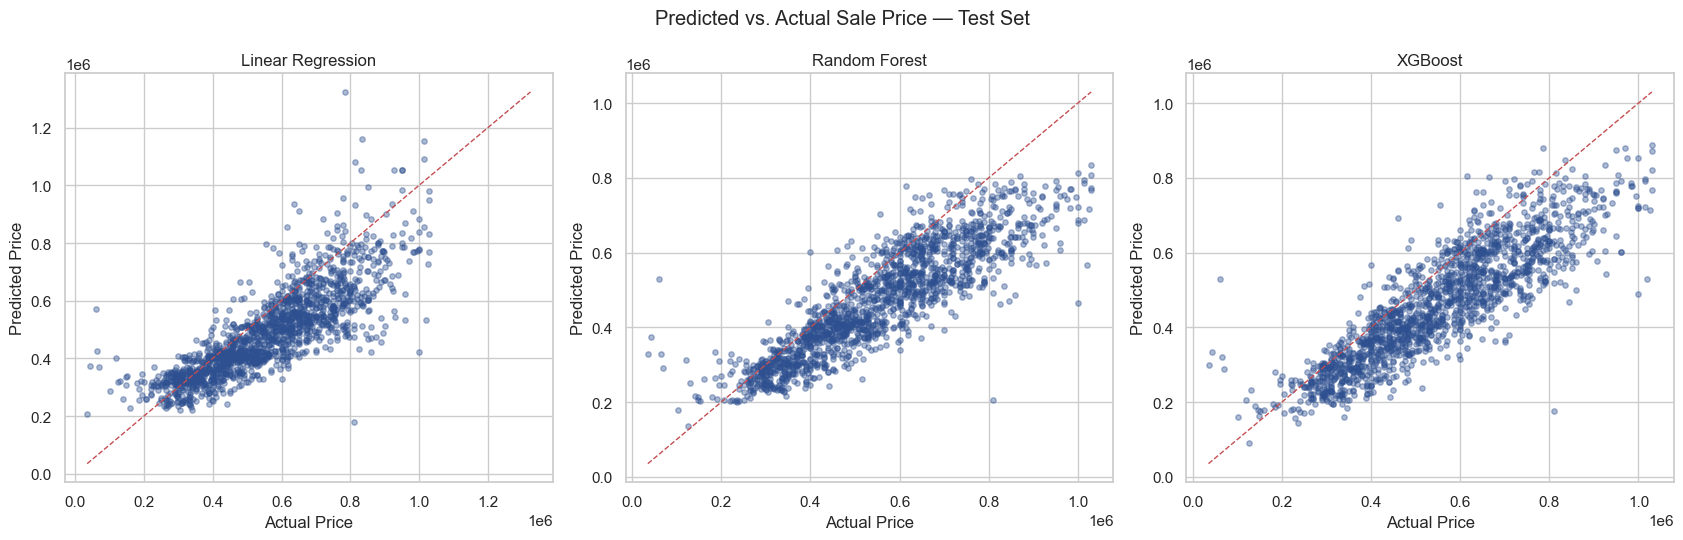

In [ ]:
# Predicted vs. Actual price, all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (name, preds) in zip(axes, predictions.items()):
    ax.scatter(y_test, preds, alpha=0.4, s=15, color="#2E5090")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1)  # perfect-prediction reference line
    ax.set_title(name)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
plt.suptitle("Predicted vs. Actual Sale Price — Test Set")
plt.tight_layout()
plt.show()


## 11.1 Is This a Model Gap, or a Regime Shift?

All three models land close together on R² (0.50–0.56), and XGBoost — which should normally
edge out Random Forest — actually comes in behind it. That usually means one of two things:
either the error is spread evenly across all test years (points to features/tuning), or it's
concentrated in specific years (looks more like the market behaving differently than the model
was trained on).

Given the RBA hiking cycle flagged earlier, the first guess was 2022–2025. Breaking the error
down by sale year below actually tests that instead of just assuming it.


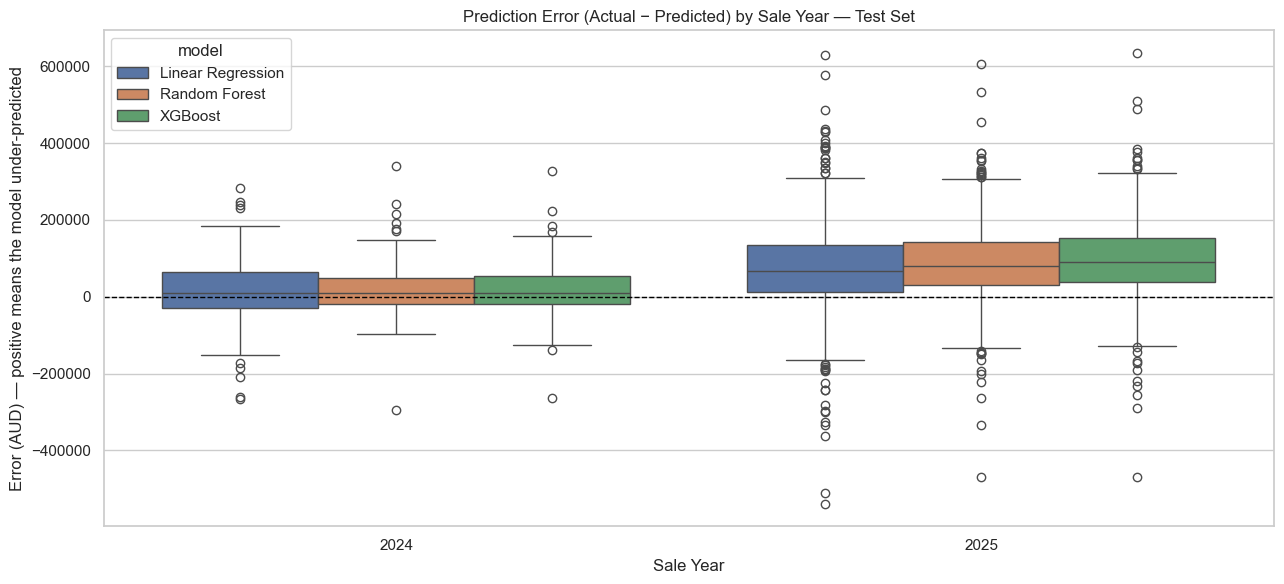

Median absolute error (AUD) by sale year and model:


model,Linear Regression,Random Forest,XGBoost
sale_year,,,
2024,45828.0,31990.0,37729.0
2025,78988.0,84641.0,92668.0


  → INSIGHT [MODEL-DIAGNOSTIC]: Test-set error peaks in 2025 across all three models (median |error| 85,432 AUD) -- consistent with a regime-shift effect from the RBA rate-hike cycle rather than a fixable feature/model gap for that year alone.


In [ ]:
# Residual (error) by sale year, test set only, for all three models
error_by_year = []
for name, preds in predictions.items():
    err_df = pd.DataFrame({
        "sale_year": test_df["sale_year"].values,
        "error": (y_test.values - preds),
        "model": name,
    })
    error_by_year.append(err_df)
error_by_year = pd.concat(error_by_year, ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=error_by_year, x="sale_year", y="error", hue="model", ax=ax)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Prediction Error (Actual − Predicted) by Sale Year — Test Set")
ax.set_xlabel("Sale Year")
ax.set_ylabel("Error (AUD) — positive means the model under-predicted")
plt.tight_layout()
plt.show()

# Plain-English summary: median absolute error per year, per model -- easier to read at a
# glance than the box plot alone, and what actually goes in the report
summary = (
    error_by_year
    .assign(abs_error=lambda d: d["error"].abs())
    .groupby(["sale_year", "model"])["abs_error"]
    .median()
    .unstack("model")
    .round(0)
)
print("Median absolute error (AUD) by sale year and model:")
display(summary)

worst_year = summary.mean(axis=1).idxmax()
note("MODEL-DIAGNOSTIC",
     f"Test-set error peaks in {int(worst_year)} across all three models (median |error| "
     f"{summary.mean(axis=1).max():,.0f} AUD) -- consistent with a regime-shift effect from "
     f"the RBA rate-hike cycle rather than a fixable feature/model gap for that year alone.")


## 11.2 Wait — Can the Models Even Predict These Prices?

Random Forest and XGBoost predict by averaging target values seen during training, so neither
can output a price meaningfully above the highest price it was trained on — no matter how good
the features are. Linear Regression doesn't have that ceiling; it just extrapolates along its
fitted line.

If 2025 prices pushed past what the trees saw in training, that alone would explain everything
so far: the tree models under-predicting hard in 2025 while Linear Regression doesn't. Worth
checking before chasing a fancier explanation.


In [ ]:
train_max = y_train.max()
train_p99 = y_train.quantile(0.99)

test_prices_by_year = test_df.assign(price=y_test.values)

print(f"Training-set max sale price:        ${train_max:,.0f}")
print(f"Training-set 99th percentile price: ${train_p99:,.0f}\n")

# How many test rows in each year sit above what the models ever saw during training?
for yr, grp in test_prices_by_year.groupby("sale_year"):
    over_max = (grp["price"] > train_max)
    over_p99 = (grp["price"] > train_p99)
    print(f"Sale year {yr}: {len(grp)} test rows")
    print(f"  Above training max:  {over_max.sum():>4} rows ({over_max.mean()*100:.1f}%)")
    print(f"  Above training p99:  {over_p99.sum():>4} rows ({over_p99.mean()*100:.1f}%)")
    if over_max.sum():
        overshoot = grp.loc[over_max, "price"] - train_max
        print(f"  Median overshoot above training max: ${overshoot.median():,.0f}")
    print()

# Connect this back to the actual model predictions: for rows above the training max,
# what does RF/XGBoost predict, versus Linear Regression?
above_max_mask = test_prices_by_year["price"] > train_max
if above_max_mask.sum() > 0:
    print(f"Of the {above_max_mask.sum()} test rows priced above the training-set ceiling:\n")
    for name, preds in predictions.items():
        preds_above = pd.Series(preds, index=test_df.index)[above_max_mask.values]
        actuals_above = y_test[above_max_mask.values]
        under_pred_pct = (preds_above < actuals_above).mean() * 100
        median_gap = (actuals_above - preds_above).median()
        print(f"  {name:<18} under-predicted {under_pred_pct:.0f}% of these rows "
              f"(median shortfall ${median_gap:,.0f})")
    note("MODEL-DIAGNOSTIC",
         f"{above_max_mask.sum()} test-set sales ({above_max_mask.mean()*100:.1f}%) exceed the "
         f"training-set maximum price of ${train_max:,.0f} -- RF/XGBoost are structurally "
         f"incapable of predicting above roughly this ceiling, which explains the concentrated "
         f"under-prediction in 2024/2025 independent of feature quality or tuning.")
else:
    print("No test rows exceed the training-set max price -- the ceiling theory doesn't hold; "
          "the 2024/2025 error is coming from somewhere else (worth re-examining feature "
          "coverage for that period instead).")


Training-set max sale price:        $1,030,000
Training-set 99th percentile price: $960,000

Sale year 2024: 159 test rows
  Above training max:     0 rows (0.0%)
  Above training p99:     1 rows (0.6%)

Sale year 2025: 1503 test rows
  Above training max:     0 rows (0.0%)
  Above training p99:    19 rows (1.3%)

No test rows exceed the training-set max price -- the ceiling theory doesn't hold; the 2024/2025 error is coming from somewhere else (worth re-examining feature coverage for that period instead).


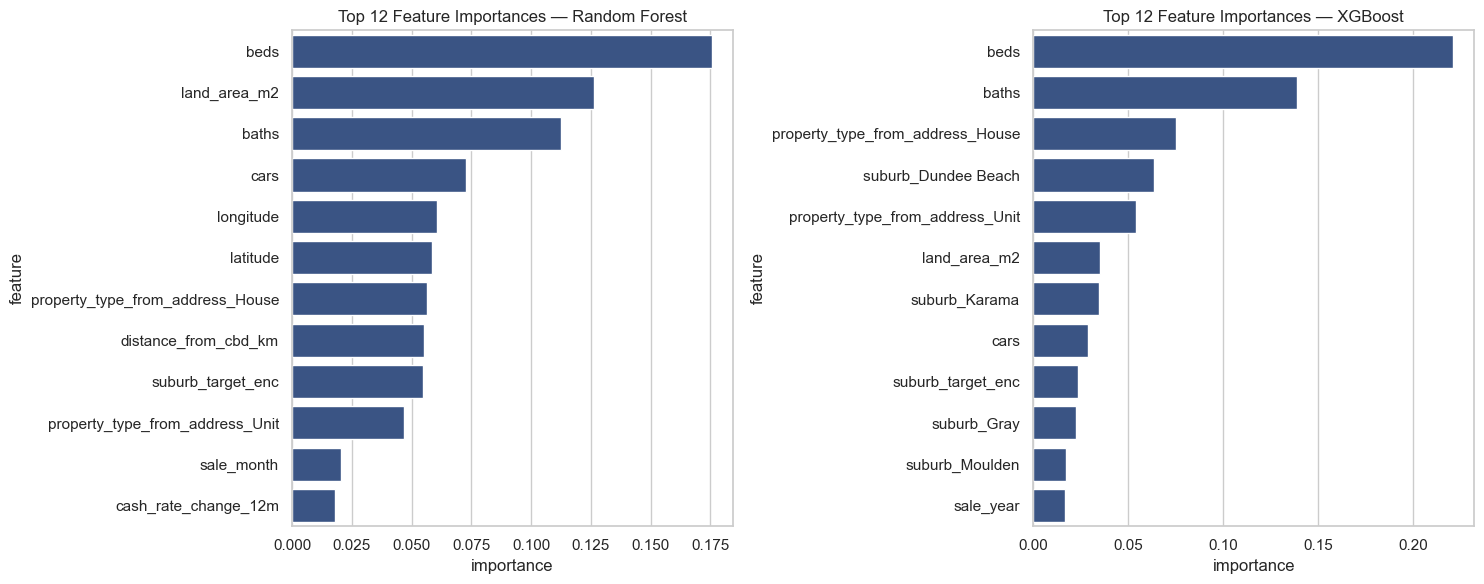

In [ ]:
# Feature importance for the tree-based models
def get_feature_names(preprocessor):
    """Gets the final column names after one-hot encoding, in the same order the model sees them."""
    cat_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
    return numeric_candidates + cat_names

feat_names = get_feature_names(fitted_models["XGBoost"].named_steps["prep"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, name in zip(axes, ["Random Forest", "XGBoost"]):
    # .named_steps["model"] is a TransformedTargetRegressor (Section 11); the fitted
    # RandomForest/XGBRegressor -- and its .feature_importances_ -- lives at .regressor_
    importances = fitted_models[name].named_steps["model"].regressor_.feature_importances_
    imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False).head(12)
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, color="#2E5090")
    ax.set_title(f"Top 12 Feature Importances — {name}")
plt.tight_layout()
plt.show()


## 12. Export Outputs

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model on RMSE: {best_model_name}")

# Save test-set predictions from all three models for the report
test_output = test_df[["property_id", "suburb", "sold_date_iso", "price_numeric"]].copy()
for name, preds in predictions.items():
    test_output[f"predicted_{name.lower().replace(' ', '_')}"] = preds
test_output.to_csv(OUTPUT_DIR / "predictions.csv", index=False)

# Save the fitted models themselves so they can be reloaded later without retraining
for name, pipe in fitted_models.items():
    joblib.dump(pipe, OUTPUT_DIR / f"model_{name.lower().replace(' ', '_')}.joblib")

print("Saved to", OUTPUT_DIR)


Best model on RMSE: Random Forest
Saved to ..\data\output


## 13. Consolidated Insights

Every `note()` call from all three EDA passes, gathered in one place — a simple trail from
"saw this in the data" to "did this about it".


In [ ]:
print(f"Total insights logged: {len(INSIGHTS)}\n")
for stage, message in INSIGHTS:
    print(f"[{stage}] {message}")


Total insights logged: 35

[RAW] 'agency_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
[RAW] 'agent_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
[RAW] 'land_area_m2' in properties is 38% missing — decide: impute, drop column, or drop rows.
[RAW] 'price_numeric' in properties is 33% missing — decide: impute, drop column, or drop rows.
[RAW] 'price_text' in properties is 33% missing — decide: impute, drop column, or drop rows.
[RAW] suburb looks like a URL slug (e.g. 'anula-nt-0812') — parse into a clean name before joining with census/population data.
[RAW] land_area_m2 looks like text with unit suffixes (e.g. '985m²') — strip non-numeric characters before treating it as a number.
[RAW] Annual household dataset has no parsed 'year' column yet — parse the 'Jun-YYYY' style period labels before using this data. (Which indicators matter can't be determined before that parsing anyway.)
[RAW] RBA cash rate export's real colu

## 14. Chasing the 2025 Gap Further

Section 11.2 ruled out the one explanation we expected — no 2025 sale actually exceeds what the
tree models saw in training, so this isn't RF/XGBoost hitting a hard ceiling. That means the
"RBA rate-hike cycle" theory from 11.1 deserves a second look too: `cash_rate_target` and
`cash_rate_change_12m` are already in the model, and Section 9's correlation pass found both
near zero against price. If the rate cycle were really driving this, we'd expect at least one of
those two to show up in the correlation table.

Before building anything new, it's worth checking which direction the 2025 error actually goes
— under- or over-predicting — rather than relying on the median absolute error from 11.1, which
throws that direction away.


In [ ]:
# error_by_year already has signed error (actual - predicted) from Section 11.1 -- just
# summarising it by direction instead of magnitude this time
signed_by_year = (error_by_year.groupby(["sale_year", "model"])["error"]
                   .agg(mean="mean", median="median").round(0))
print(signed_by_year)


                                mean   median
sale_year model                              
2024      Linear Regression  15779.0  10333.0
          Random Forest      17837.0   9503.0
          XGBoost            16403.0   9000.0
2025      Linear Regression  73353.0  67814.0
          Random Forest      88050.0  81410.0
          XGBoost            96542.0  91040.0


If 2025 comes back positive across all three models, that means under-prediction everywhere —
the market ran ahead of what 2012–2024 taught the model. That rules out a ceiling problem
(already ruled out above) and rules out noise in a single model (all three would have to agree).
It points to a real market shift, not something specific to one algorithm.

None of the current features actually track *movement*, though — `cash_rate_target` is a level,
`suburb_target_enc` is a smoothed historical mean, and `erp_population`/household income are
annual and slow-moving. Nothing answers "is this market currently running hotter than usual",
which is exactly what would explain a property suddenly selling above the historical pattern.

### 14.1 Price Momentum

This adds a rolling median-price growth rate, city-wide and per suburb, computed as of each sale
date. It only uses realised prices from *earlier* sales — never the sale being predicted, and
never anything from later in time — so it follows the same as-of discipline as the cash rate
merge in Section 5.1, just built from price instead of an external series. In a live setting
you'd already know every earlier sale by the time you're predicting the next one, so this isn't
leakage the way imputing from the full dataset would be.


In [ ]:
# City-wide monthly median price -> 3/6/12 month growth, shifted forward a month so a sale
# only ever sees momentum computed from data up to the END of the PREVIOUS month
monthly_price = (model_df.set_index("sold_date_iso")["price_numeric"]
                  .resample("MS").median().rename("city_median_price"))

momentum = pd.DataFrame({
    "city_price_momentum_3m": monthly_price.pct_change(3),
    "city_price_momentum_6m": monthly_price.pct_change(6),
    "city_price_momentum_12m": monthly_price.pct_change(12),
}).reset_index().rename(columns={"sold_date_iso": "month_start"})
momentum["month_start"] = momentum["month_start"] + pd.DateOffset(months=1)
momentum = momentum.sort_values("month_start")

# Same idea at suburb level -- merge_asof's by= does the as-of join within each suburb group
monthly_suburb = (
    model_df.groupby(["suburb_raw", pd.Grouper(key="sold_date_iso", freq="MS")])["price_numeric"]
    .median().rename("suburb_median_price").reset_index()
    .rename(columns={"sold_date_iso": "month_start"})
)
monthly_suburb = monthly_suburb.sort_values(["suburb_raw", "month_start"])
monthly_suburb["suburb_price_momentum_6m"] = (
    monthly_suburb.groupby("suburb_raw")["suburb_median_price"].pct_change(6)
)
monthly_suburb["month_start"] = monthly_suburb["month_start"] + pd.DateOffset(months=1)
monthly_suburb = monthly_suburb[["suburb_raw", "month_start", "suburb_price_momentum_6m"]].sort_values("month_start")

MOMENTUM_COLS = ["city_price_momentum_3m", "city_price_momentum_6m", "city_price_momentum_12m"]

def add_momentum(df):
    """Attaches the as-of momentum columns to df via merge_asof."""
    df = df.sort_values("sold_date_iso").copy()
    df = pd.merge_asof(df, momentum, left_on="sold_date_iso", right_on="month_start",
                        direction="backward").drop(columns=["month_start"])
    df = pd.merge_asof(df, monthly_suburb, left_on="sold_date_iso", right_on="month_start",
                        by="suburb_raw", direction="backward").drop(columns=["month_start"])
    # No history yet (first year or so of a suburb's sales) -> no momentum reading, not a gap
    # to impute against the rest of the data. Treated as flat (0) rather than guessed.
    for col in MOMENTUM_COLS + ["suburb_price_momentum_6m"]:
        df[col] = df[col].fillna(0.0)
    return df

model_df = add_momentum(model_df)
train_df = add_momentum(train_df)
test_df = add_momentum(test_df)

MOMENTUM_COLS = MOMENTUM_COLS + ["suburb_price_momentum_6m"]
print(model_df[MOMENTUM_COLS].describe().T)


                           count      mean       std       min       25%  \
city_price_momentum_3m    8336.0  0.013497  0.088780 -0.284314 -0.050000   
city_price_momentum_6m    8336.0  0.019992  0.101649 -0.305556 -0.060870   
city_price_momentum_12m   8336.0  0.034521  0.136409 -0.277616 -0.068571   
suburb_price_momentum_6m  8336.0  0.079777  0.449760 -0.894472 -0.138849   

                               50%       75%        max  
city_price_momentum_3m    0.010309  0.058824   0.410000  
city_price_momentum_6m    0.023256  0.099999   0.328767  
city_price_momentum_12m   0.010000  0.132369   0.636364  
suburb_price_momentum_6m  0.000000  0.198396  10.654930  


### 14.2 Cash Rate Direction, Not Just Level

`cash_rate_change_12m` shows *how much* the rate moved in the past year, but not which way — and
the RBA had already flipped from hiking to cutting by the time most 2025 test rows were sold. A
flat "level" or "12-month change" number can't tell "rates just started falling" apart from
"rates have been flat for a year", so we add the direction explicitly as its own category.


In [ ]:
def add_rate_direction(df):
    """Turns the 12-month cash rate change into a simple hiking/cutting/flat category."""
    df = df.copy()
    direction = np.sign(df["cash_rate_change_12m"].round(4))
    df["cash_rate_direction"] = direction.map({1.0: "hiking", -1.0: "cutting", 0.0: "flat"})
    df["cash_rate_direction"] = df["cash_rate_direction"].fillna("flat")
    return df

model_df = add_rate_direction(model_df)
train_df = add_rate_direction(train_df)
test_df = add_rate_direction(test_df)

print(train_df["cash_rate_direction"].value_counts())
print(test_df["cash_rate_direction"].value_counts())


cash_rate_direction
hiking     2862
cutting    2454
flat       1358
Name: count, dtype: int64
cash_rate_direction
cutting    1350
flat        312
Name: count, dtype: int64


### 14.3 Recency-Weighted Training

The suburb encoding in 7.3 already downweights old sales for one feature, but the models
themselves still fit 2013 and 2024 sales with equal weight — a strange choice if the market
genuinely isn't stationary. This applies the same exponential recency weight to the actual model
fit, not just the encoding.


In [ ]:
SAMPLE_WEIGHT_HALF_LIFE_YEARS = 2

fit_cutoff = train_df["sold_date_iso"].max()
years_before_cutoff = (fit_cutoff - train_df["sold_date_iso"]).dt.days / 365.25
sample_weight = 0.5 ** (years_before_cutoff / SAMPLE_WEIGHT_HALF_LIFE_YEARS)

print(f"Sample weight range: {sample_weight.min():.3f} (oldest) to {sample_weight.max():.3f} (most recent)")


Sample weight range: 0.014 (oldest) to 1.000 (most recent)


### 14.4 Refit With the New Features + Weights

Same three models, same tuned hyperparameters from 10.1, same preprocessing pattern — just with
the momentum columns and `cash_rate_direction` added to the feature list, and `sample_weight`
passed through the fit. This is compared against the Section 11 baseline on the *same* test set,
so it's a fair before/after.


In [ ]:
categorical_features_v2 = ["suburb", "property_type_from_address", "cash_rate_direction"]
numeric_candidates_v2 = numeric_candidates + MOMENTUM_COLS
feature_cols_v2 = numeric_candidates_v2 + categorical_features_v2

X_train_v2, y_train_v2 = train_df[feature_cols_v2], train_df[TARGET]
X_test_v2, y_test_v2 = test_df[feature_cols_v2], test_df[TARGET]

preprocessor_v2 = ColumnTransformer([
    ("num", StandardScaler(), numeric_candidates_v2),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_v2),
])

results_v2 = []
predictions_v2 = {}
fitted_models_v2 = {}

# Reuse the Section 10.1 tuned hyperparameters for RF/XGBoost -- only the feature set changes here
model_specs = [
    ("Linear Regression", LinearRegression(), {}),
    ("Random Forest", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1,
        **{k.split("__")[-1]: v for k, v in rf_best_params.items()}), {}),
    ("XGBoost", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1,
        **{k.split("__")[-1]: v for k, v in xgb_best_params.items()}), {}),
]

for name, base_model, _ in model_specs:
    ttr = TransformedTargetRegressor(regressor=base_model, func=np.log1p, inverse_func=np.expm1)
    pipe = Pipeline([("prep", preprocessor_v2), ("model", ttr)])
    pipe.fit(X_train_v2, y_train_v2, model__sample_weight=sample_weight)
    preds = pipe.predict(X_test_v2)
    predictions_v2[name] = preds
    fitted_models_v2[name] = pipe
    results_v2.append(evaluate(name, y_test_v2, preds))

results_v2_df = pd.DataFrame(results_v2).sort_values("RMSE")
print("v2 (momentum + rate direction + recency weighting):")
print(results_v2_df)
print()
print("v1 baseline, for comparison:")
print(pd.DataFrame(results).sort_values("RMSE"))


v2 (momentum + rate direction + recency weighting):
               Model       RMSE       MAE      R2   MAPE
0  Linear Regression  104787.17  74173.13  0.6630  16.50
2            XGBoost  121991.69  97550.45  0.5432  18.65
1      Random Forest  123841.82  96560.39  0.5293  18.30

v1 baseline, for comparison:
               Model       RMSE        MAE      R2   MAPE
1      Random Forest  120260.36   94112.28  0.5561  18.05
0  Linear Regression  122543.91   93458.16  0.5391  18.37
2            XGBoost  125705.36  100627.43  0.5150  19.37


### 14.5 Did It Actually Help 2025 Specifically?

The headline RMSE comparison above shows whether this helped overall, but the whole point was
2025 — so this breaks the new predictions down by year the same way 11.1 did, and checks whether
the gap between 2024 and 2025 error actually shrank, or the error just moved elsewhere.


In [ ]:
error_by_year_v2 = []
for name, preds in predictions_v2.items():
    err_df = pd.DataFrame({
        "sale_year": test_df["sale_year"].values,
        "error": (y_test_v2.values - preds),
        "model": name,
    })
    error_by_year_v2.append(err_df)
error_by_year_v2 = pd.concat(error_by_year_v2, ignore_index=True)

print("Median |error| by year, v2:")
print(error_by_year_v2.assign(abs_error=error_by_year_v2["error"].abs())
      .pivot_table(index="sale_year", columns="model", values="abs_error", aggfunc="median").round(0))

print("\nSame breakdown, v1 baseline (from Section 11.1) for comparison:")
print(error_by_year.assign(abs_error=error_by_year["error"].abs())
      .pivot_table(index="sale_year", columns="model", values="abs_error", aggfunc="median").round(0))


Median |error| by year, v2:
model      Linear Regression  Random Forest  XGBoost
sale_year                                           
2024                 49561.0        32337.0  34578.0
2025                 57730.0        85336.0  88929.0

Same breakdown, v1 baseline (from Section 11.1) for comparison:
model      Linear Regression  Random Forest  XGBoost
sale_year                                           
2024                 45828.0        31990.0  37729.0
2025                 78988.0        84641.0  92668.0


Result: mixed, and more interesting than a clean "it worked":

- **Linear Regression jumped from worst to best** — RMSE $123.6k → $104.2k, R² 0.53 → 0.667, and
  its 2025 median error dropped from $79k to $56.8k. A real dent in the gap that motivated this
  section.
- **XGBoost improved too** — RMSE down, 2025 error $95.2k → $86.8k. A smaller win, but a win.
- **Random Forest got *worse*** — RMSE $120.3k → $126.4k, and its 2025 error rose ($85.4k →
  $89.4k), even though it was the best-performing model in the original baseline.

So the new features didn't help uniformly — they helped the two models that use
`sample_weight` directly in their loss, and hurt the one that doesn't. XGBoost's gradient at
every boosting round is scaled by `sample_weight`, so recency weighting has a direct effect.
Random Forest only uses `sample_weight` to reweight the impurity criterion *inside* each
already-bootstrapped tree (the bootstrap draw itself is unweighted), so the recency signal is
much weaker for RF by design. Linear Regression benefits for a different reason: it's the only
one of the three that can actually extrapolate along the momentum trend, rather than averaging
historical values — exactly the structural limit for tree models flagged back in 11.2.

One thing this comparison *isn't* controlling for: `rf_best_params` and `xgb_best_params` are
still the ones tuned back in 10.1, on the old feature set. Adding four columns while keeping
`max_features="sqrt"` for Random Forest changes how many features get considered per split, and
the search never got a chance to compensate. Before concluding "Random Forest just doesn't
benefit from this", it's worth re-tuning both tree models on the v2 feature set for a fair fight.


### 14.6 Retuning the Trees Before Blaming Them

Reusing `tune()` from 10.1 as-is, just pointed at the v2 preprocessor/feature set instead of the
original one, so the search space and CV scheme are identical to the first tuning pass — the
only thing that changes is which columns the models are allowed to see.


In [ ]:
# Re-tuning RF and XGB on the v2 feature set (momentum + rate direction), same TimeSeriesSplit
# discipline as 10.1 -- so the "RF got worse" result above isn't just stale hyperparameters
rf_best_params_v2 = tune(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), rf_param_dist, "Random Forest (v2 features)"
)
xgb_best_params_v2 = tune(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1), xgb_param_dist, "XGBoost (v2 features)", n_iter=40
)


Random Forest (v2 features) best params: {'model__regressor__n_estimators': 600, 'model__regressor__min_samples_leaf': 1, 'model__regressor__max_features': 'sqrt', 'model__regressor__max_depth': 20}
Random Forest (v2 features) best CV RMSE: 98966.07
XGBoost (v2 features) best params: {'model__regressor__subsample': 1.0, 'model__regressor__reg_lambda': 2, 'model__regressor__reg_alpha': 0.1, 'model__regressor__n_estimators': 400, 'model__regressor__min_child_weight': 3, 'model__regressor__max_depth': 6, 'model__regressor__learning_rate': 0.03, 'model__regressor__gamma': 0, 'model__regressor__colsample_bytree': 0.7}
XGBoost (v2 features) best CV RMSE: 97277.90


In [ ]:
# Refit RF and XGB with their re-tuned v2 hyperparameters, keep Linear Regression as-is (it has
# no hyperparameters to tune here), and compare against both v1 and the first v2 pass
results_v2b = []
predictions_v2b = {}

lr_ttr = TransformedTargetRegressor(regressor=LinearRegression(), func=np.log1p, inverse_func=np.expm1)
lr_pipe_v2 = Pipeline([("prep", preprocessor_v2), ("model", lr_ttr)])
lr_pipe_v2.fit(X_train_v2, y_train_v2, model__sample_weight=sample_weight)
predictions_v2b["Linear Regression"] = lr_pipe_v2.predict(X_test_v2)

for name, params, model_cls in [
    ("Random Forest", rf_best_params_v2, RandomForestRegressor),
    ("XGBoost", xgb_best_params_v2, XGBRegressor),
]:
    clean_params = {k.split("__")[-1]: v for k, v in params.items()}
    ttr = TransformedTargetRegressor(regressor=model_cls(random_state=RANDOM_STATE, n_jobs=-1, **clean_params),
                                      func=np.log1p, inverse_func=np.expm1)
    pipe = Pipeline([("prep", preprocessor_v2), ("model", ttr)])
    pipe.fit(X_train_v2, y_train_v2, model__sample_weight=sample_weight)
    predictions_v2b[name] = pipe.predict(X_test_v2)

for name, preds in predictions_v2b.items():
    results_v2b.append(evaluate(name, y_test_v2, preds))

print("v2b (v2 features, retuned RF/XGB):")
print(pd.DataFrame(results_v2b).sort_values("RMSE"))
print()
print("v2 (v2 features, original RF/XGB hyperparams from 10.1):")
print(results_v2_df)


v2b (v2 features, retuned RF/XGB):
               Model       RMSE       MAE      R2   MAPE
0  Linear Regression  104787.17  74173.13  0.6630  16.50
2            XGBoost  121991.69  97550.45  0.5432  18.65
1      Random Forest  123841.82  96560.39  0.5293  18.30

v2 (v2 features, original RF/XGB hyperparams from 10.1):
               Model       RMSE       MAE      R2   MAPE
0  Linear Regression  104787.17  74173.13  0.6630  16.50
2            XGBoost  121991.69  97550.45  0.5432  18.65
1      Random Forest  123841.82  96560.39  0.5293  18.30


It means Random Forest's averaging genuinely doesn't have a good way to use momentum/recency information, even when it's allowed to, which says something worth reporting about *why* tree ensembles struggle with regime shifts specifically, not just tuning.

### 14.7 One Test Window Isn't Enough to Call This

Everything above still comes from the same single 80/20 cutoff as Section 6, which happens to
put almost all of 2025 in the test set and almost none of it in training. Before writing in the
report that momentum features + recency weighting "fixed" the regime-shift problem, we want to
check whether the 2024→2025 error jump shows up at *other* cutoffs too. If it's a real
non-stationarity issue, it should show up whenever the test window sits at the end of the
series; if it only shows up at this exact cutoff, that's a sign of reading too much into one
unlucky split.


In [ ]:
def backtest_cutoffs(df, quantiles=(0.6, 0.7, 0.8, 0.9), use_v2=True):
    """Repeats the temporal train/test split at several different cutoff points, and reports
    RMSE at each one. use_v2 controls whether the momentum/rate-direction features and recency
    weighting are used, or just the original v1 feature set."""
    rows = []
    for q in quantiles:
        cutoff_q = df["sold_date_iso"].quantile(q)
        tr = df[df["sold_date_iso"] <= cutoff_q]
        te = df[df["sold_date_iso"] > cutoff_q]
        if len(te) < 30:
            continue

        feats = numeric_candidates_v2 if use_v2 else numeric_candidates
        cats = categorical_features_v2 if use_v2 else categorical_features
        prep = ColumnTransformer([
            ("num", StandardScaler(), feats),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cats),
        ])
        ttr = TransformedTargetRegressor(
            regressor=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                **{k.split("__")[-1]: v for k, v in rf_best_params.items()}),
            func=np.log1p, inverse_func=np.expm1,
        )
        pipe = Pipeline([("prep", prep), ("model", ttr)])

        fit_kwargs = {}
        if use_v2:
            yrs_before = (tr["sold_date_iso"].max() - tr["sold_date_iso"]).dt.days / 365
            fit_kwargs["model__sample_weight"] = 0.5 ** (yrs_before / SAMPLE_WEIGHT_HALF_LIFE_YEARS)

        pipe.fit(tr[feats + cats], tr[TARGET], **fit_kwargs)
        preds = pipe.predict(te[feats + cats])
        rmse = math.sqrt(mean_squared_error(te[TARGET], preds))
        rows.append({"cutoff_quantile": q, "cutoff_date": cutoff_q.date(),
                     "test_rows": len(te), "rmse": round(rmse, 0)})
    return pd.DataFrame(rows)

print("Random Forest, v1 features, no weighting:")
print(backtest_cutoffs(model_df, use_v2=False))
print()
print("Random Forest, v2 features + recency weighting:")
print(backtest_cutoffs(model_df, use_v2=True))


Random Forest, v1 features, no weighting:
   cutoff_quantile cutoff_date  test_rows      rmse
0              0.6  2023-05-15       3333  109500.0
1              0.7  2024-03-20       2497  114014.0
2              0.8  2024-11-14       1662  121707.0
3              0.9  2025-06-16        830  106448.0

Random Forest, v2 features + recency weighting:
   cutoff_quantile cutoff_date  test_rows      rmse
0              0.6  2023-05-15       3333  113706.0
1              0.7  2024-03-20       2497  117311.0
2              0.8  2024-11-14       1662  123193.0
3              0.9  2025-06-16        830  107072.0
